In [1]:
%matplotlib inline
import time
import numpy as np
import scipy.optimize as op
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import scipy.linalg as linalg
import IPython
import emcee
import os
from multiprocessing.pool import ThreadPool
from matplotlib.ticker import MaxNLocator
from getdist import plots, MCSamples, loadMCSamples, types
from scipy.special import gamma
from scipy.integrate import quad

os.environ["OMP_NUM_THREADS"] = "1"

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",             # Usa fonte serifada
    "font.serif": ["Palatino"],         # Especifica a fonte padrão do LaTeX
    "axes.labelsize": 16,               # Tamanho dos rótulos (H0, Wm)
    "font.size": 14,                    # Tamanho geral
    "legend.fontsize": 14,              # Tamanho da legenda
    "xtick.labelsize": 12,              # Tamanho dos números no eixo X
    "ytick.labelsize": 12,              # Tamanho dos números no eixo Y
})

np.random.seed(321)

# Carregando os dados

In [2]:
zhzi, hzi, shzi, metodo = np.genfromtxt('data/Hz33Clocks.txt', comments='#', usecols=(0,1,2,3), unpack=True, dtype=('f8', 'f8', 'f8', 'U1'))
zmod, imf, slib, sps, spsooo = np.genfromtxt('data/data_MM20.dat', comments='#', usecols=(0,1,2,3,4), unpack=True)

In [3]:
priorArray = np.array([[50., 100.], [0.0, 3.0], [-3.0, 3.0], [0.1, 2]])
nstepHz = 5000
ndata = len(zhzi)

In [4]:
z_FSF, h_FSF, sH_FSF = [], [], []
z_d4000, h_d4000, sH_d4000 = [], [], []
for i in range(ndata):
    if metodo[i] == 'F':
        z_FSF.append(zhzi[i])
        h_FSF.append(hzi[i])
        sH_FSF.append(shzi[i])
    elif metodo[i] == 'D':
        z_d4000.append(zhzi[i])
        h_d4000.append(hzi[i])
        sH_d4000.append(shzi[i])
z_FSF = np.array(z_FSF)
h_FSF = np.array(h_FSF)
sH_FSF = np.array(sH_FSF)
z_d4000 = np.array(z_d4000)
h_d4000 = np.array(h_d4000)
sH_d4000 = np.array(sH_d4000)

# Funções de análise

In [18]:
#Function to identify which model will be used
def free_par(theta, freef, flat):
    if freef == True:
        if flat == False:
            h0, wm, wl, f = theta
            return [h0, wm, wl, f]
        elif flat == True:
            h0, wm, f = theta
            return [h0, wm, 1-wm, f]
        else:
            print("Invalid flatness...")
            return None
    elif freef == False:
        if flat == False:
            h0, wm, wl = theta
            return [h0, wm, wl, 1]
        elif flat == True:
            h0, wm = theta
            return [h0, wm, 1-wm, 1]
        else:
            print("Invalid flatness...")
            return None
    else:
        print("Invalid correction parameter...")
        return None

#Calculate chi2 for the model
def chi2Hz(par, met):
    if met == 'D4000':
        z = z_d4000
        hz = h_d4000
    elif met == 'FSF':
        z = z_FSF
        hz = h_FSF
    E2 = par[1]*(1+z)**3+(1-par[1]-par[2])*(1+z)**2+par[2]

    if np.any(E2<0):
        return np.inf

    Hzm = par[0]*np.sqrt(E2)
    dhz = hz-Hzm
    inv_covCorr = inv_cov/par[3]**2

    return np.dot(np.dot(dhz.T, inv_covCorr), dhz)

#Check if parameters are in prior interval
def lnpriorHz(par):
    for i in range(len(par)):
        if not priorArray[i][0] < par[i] < priorArray[i][1]:
            return -np.inf
    return 0.0

#Calculate the likelihood
def lnlikeHz(par, met):
    chi2 = chi2Hz(par, met)
    if met == 'D4000':
        n = ndata_d4000
    elif met == 'FSF':
        n = ndata_FSF
    return -0.5*chi2 - n*np.log(par[3])

def lnprobHz(theta, freef, flat, met):
    par = free_par(theta, freef, flat)
    
    lp = lnpriorHz(par)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikeHz(par, met)

#Minimize chi2
def find_bestfit(lnlike, par_ml, parnames, freef, flat, met):
    t1 = time.time()
    ndim = len(par_ml)
    chi2 = lambda par_ml, freef, flat, met: -2*lnlike(par_ml, freef, flat, met)
    result = op.minimize(chi2, par_ml, args=(freef, flat, met))
    if not result['success']:
        result = op.minimize(chi2, par_ml, args=(freef, flat, met), method='Nelder-Mead', options={'maxiter': 10000})
    par_ml = result['x']
    print('Maximum likelihood result:')
    for i in range(ndim):
        print(parnames[i],' = ',par_ml[i])
    print('chi2min =',result['fun'])
    t2 = time.time()
    print('Total time: {0:5.3f} seg'.format(t2-t1))
    return result

#Run MC
def run_emcee(par_ml, nwalkers, lnprob, freef, flat, met, ainput, nsteps):
    ndim = len(par_ml)
    pos = [par_ml +1e-4*np.random.randn(ndim) for i in range(nwalkers)]
    
    with ThreadPool() as pool:
        sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=[freef, flat, met], a=ainput, pool=pool)
        sampler.run_mcmc(pos, nsteps, progress=True)
    
    accept = sampler.acceptance_fraction
    print('Acceptance fraction:',accept)
    print('Minimum acceptance:',np.amin(accept))
    print('Maximum acceptance:',np.amax(accept))
    
    return sampler

#Remove burn in
def tira_burnin(sampler, burnin, ndim):
    samples = sampler.chain[:, burnin:, :].reshape((-1, ndim))
    return samples


def burninthin(sampler, tau):
    taumax = np.amax(tau)
    taumin = np.amin(tau)
    samples = sampler.get_chain(discard=int(2*taumax), thin=int(taumin/2), flat=True)
    print(samples.shape)
    return samples

#MC results
def MC_result(samples, par_ml, parnames):
    ndim = len(par_ml)
    par_mean = np.mean(samples,axis=0)
    par_median = np.percentile(samples, [50], axis=0)[0]
    par_valm = np.percentile(samples, [15.865525393149998], axis=0)[0]
    par_valp = np.percentile(samples, [84.13447460685], axis=0)[0]
    par_valm2 = np.percentile(samples, [2.275013194800002], axis=0)[0]
    par_valp2 = np.percentile(samples, [97.7249868052], axis=0)[0]
    par_sigm = par_mean - par_valm
    par_sigp = par_valp - par_mean
    par_sigm2 = par_mean - par_valm2
    par_sigp2 = par_valp2 - par_mean
    print('MCMC result:')
    for i in range(ndim):
        print("""{0} = {1:5.5f} +{2:5.5f} +{3:5.5f} -{4:5.5f} -{5:5.5f} (median: {6:5.5f}, ml: {7:5.5f})"""\
              .format(parnames[i],par_mean[i],par_sigp[i],par_sigp2[i],par_sigm[i],par_sigm2[i],par_median[i],par_ml[i]))

def best_par(samples):
    return np.mean(samples,axis=0)

#Insert a derived paramater
def insertDerived(sample, parnames, parlabel, num, gsample, derived, derivedName, derivedLabel):
    n = np.zeros(num)
    
    if derivedName not in parnames:
        newSample = np.c_[sample, derived]
        parnames.append(derivedName)
        gsample.addDerived(derived, name=derivedName, label=derivedLabel)
        
        return newSample, gsample, parnames, n

    elif derivedName in parnames:
        print('Parâmetro dependente já adicionado.')

        return sample, gsample, parnames, n

#Distribution funcion for chi2
def chiDist(chi, n):
    return (n**(n/2)*((chi)**((n-2)/2))*np.exp(-(n/2)*chi))/(2**(n/2)*gamma(n/2))

#Calculate cdf for chiDist
def chiCDF(x, n):
    res = np.zeros_like(x)
    val_max = 0
    for i, val in enumerate(x):
        y, err = quad(chiDist, 0, val, args=(n))
        res[i]=y
    return res

#Plot chi2 cdf
def plotChiDist(chimin, par, ndata, name=0):
    n = ndata - par
    chi = np.linspace(0, 2.5, 500)
    chiv = np.full((500), chimin/n)
    hv = chiDist(chi, n)
    cdf = chiCDF(chi, n)
    y = np.linspace(0, 1.8, 500)
    moda = 1 - 2/n
    
    plt.plot(chi, hv, label=r"$h _{\nu}$")
    plt.plot(chi, cdf, label="CDF")
    plt.plot(np.full((500), moda), y, '--', label=r"$(\chi ^{2} _{\nu})_{\mathrm{mp}}$" + "$= {0}$".format(np.round(moda, 3)))
    plt.plot(chiv, y, '--', label=r"$\chi _{\nu} ^{2}$" + "$= {0}$".format(np.round(chimin/n, 3)))
    
    plt.xticks(np.arange(0.0, 2.51, 0.5))
    plt.yticks(np.arange(0.0, 1.76, 0.25))
    plt.axis((0, 2.5, 0, 1.75))
    plt.grid(linestyle='-.', linewidth='0.5')
    plt.minorticks_on()
    
    plt.ylabel(r'$h_{\nu}$')
    plt.xlabel(r'$\chi _{\nu} ^{2}$')
    plt.legend(loc='best')
   
    if not name == 0:
        plt.savefig('fig/'+name+'.pdf')
    
    plt.show()

def MCResult(sampler):
    if hasattr(sampler, 'products'):
        gdsamples = sampler.products()['sample'][0].to_getdist()
    else:
        gdsamples = sampler
    
    stats = gdsamples.getMargeStats()

    resultados = {'params': {}}

    for parametro in stats.names:
        par_stats = stats.parWithName(parametro.name)

        media = par_stats.mean

        # Erros de 1s
        inf_1s = par_stats.limits[0].lower
        sup_1s = par_stats.limits[0].upper

        # Erros de 2s
        inf_2s = par_stats.limits[1].lower
        sup_2s = par_stats.limits[1].upper

        print(f'{parametro.name} = {media:.4f} + {(sup_1s - media):.4f} + {(sup_2s - media):.4f} -{(media - inf_1s):.4f} -{(media - inf_2s):.4f}')

# Análise FSF

In [6]:
ndata_FSF = len(z_FSF)
cov_mat_diag = np.zeros((ndata_FSF, ndata_FSF), dtype='float64')

for i in range(ndata_FSF):
    cov_mat_diag[i,i] = sH_FSF[i]**2

imf_intp = np.interp(z_FSF, zmod, imf)/100
spsooo_intp = np.interp(z_FSF, zmod, spsooo)/100

cov_mat_imf = np.zeros((ndata_FSF, ndata_FSF), dtype='float64')
cov_mat_spsooo = np.zeros((ndata_FSF, ndata_FSF), dtype='float64')

for i in range(ndata_FSF):
    for j in range(ndata_FSF):
        cov_mat_imf[i,j] = h_FSF[i] * imf_intp[i] * h_FSF[j] * imf_intp[j]
        cov_mat_spsooo[i,j] = h_FSF[i] * spsooo_intp[i] * h_FSF[j] * spsooo_intp[j]

cov_mat = cov_mat_imf + cov_mat_spsooo + cov_mat_diag
inv_cov = linalg.inv(cov_mat)

### OLCDM sem correção

In [7]:
par_HzC = [69.1929957609451,0.2480895086492853, 0.6862431649000225]
ndimC = len(par_HzC)
prefixC = 'LcdmHz32Cov'
parlabelsC = ["H_0","\\Omega_m", "\\Omega_\\Lambda"]
parlabtexC = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$"]
parnamesC = ['H0','wm','wl']

resultHzC = find_bestfit(lnprobHz, par_HzC, parnamesC, freef=False, flat=False, met='FSF')
par_HzC = resultHzC['x']

Maximum likelihood result:
H0  =  66.96881038331254
wm  =  7.1396716279563e-08
wl  =  0.09814790169486
chi2min = 7.410341514223805
Total time: 0.020 seg


/home/nirk/miniforge3/envs/cosmo_env/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/home/nirk/miniforge3/envs/cosmo_env/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/home/nirk/miniforge3/envs/cosmo_env/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


In [8]:
samplerHzC = run_emcee(par_HzC, 100, lnprobHz, False, False, 'FSF', 2.0, nstepHz)

  0%|                                                  | 0/5000 [00:00<?, ?it/s]/home/nirk/miniforge3/envs/cosmo_env/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████████████████████████████████| 5000/5000 [00:27<00:00, 179.47it/s]

Acceptance fraction: [0.592  0.5914 0.5682 0.588  0.5874 0.5842 0.6018 0.5956 0.6146 0.5896
 0.5726 0.5928 0.5706 0.5872 0.5784 0.5932 0.6058 0.5892 0.6004 0.5872
 0.5962 0.6052 0.5784 0.5846 0.5952 0.6156 0.5908 0.5884 0.596  0.6176
 0.5828 0.5908 0.592  0.611  0.6048 0.5898 0.5974 0.5984 0.5786 0.5904
 0.5774 0.591  0.6016 0.5932 0.5796 0.6026 0.5964 0.5998 0.6048 0.5844
 0.6078 0.6042 0.5942 0.5968 0.5832 0.6112 0.59   0.584  0.5878 0.5984
 0.584  0.5962 0.6058 0.5796 0.5894 0.5848 0.586  0.5894 0.5926 0.591
 0.6018 0.584  0.594  0.6052 0.5882 0.596  0.5932 0.5866 0.6028 0.5952
 0.5862 0.5942 0.5856 0.5984 0.5838 0.5868 0.5946 0.5828 0.5778 0.5846
 0.588  0.6016 0.5944 0.5958 0.606  0.5852 0.6042 0.6026 0.5928 0.5874]
Minimum acceptance: 0.5682
Maximum acceptance: 0.6176


In [9]:
tauHzC = samplerHzC.get_autocorr_time()
print(tauHzC)

tauHzmaxC = np.amax(tauHzC)
r = nstepHz/tauHzmaxC
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[49.9232012  46.77654423 51.03910241]
97.9641052404524
Convergiu! :)


In [10]:
samplesHzC = burninthin(samplerHzC, 100)

(9600, 3)


In [11]:
MC_result(samplesHzC, par_HzC, parnamesC)

MCMC result:
H0 = 67.97040 +9.13960 +19.17122 -9.55772 -15.97408 (median: 67.65043, ml: 66.96881)
wm = 0.30098 +0.23227 +0.52686 -0.22359 -0.29020 (median: 0.25998, ml: 0.00000)
wl = 0.56272 +0.54089 +1.03118 -0.51638 -1.02266 (median: 0.54258, ml: 0.09815)


In [12]:
gsamplesHzC_FSF = MCSamples(samples=samplesHzC, names=parnamesC, labels=parlabelsC, ranges={'wm':(0, None)})
gsamplesHzC_FSF.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


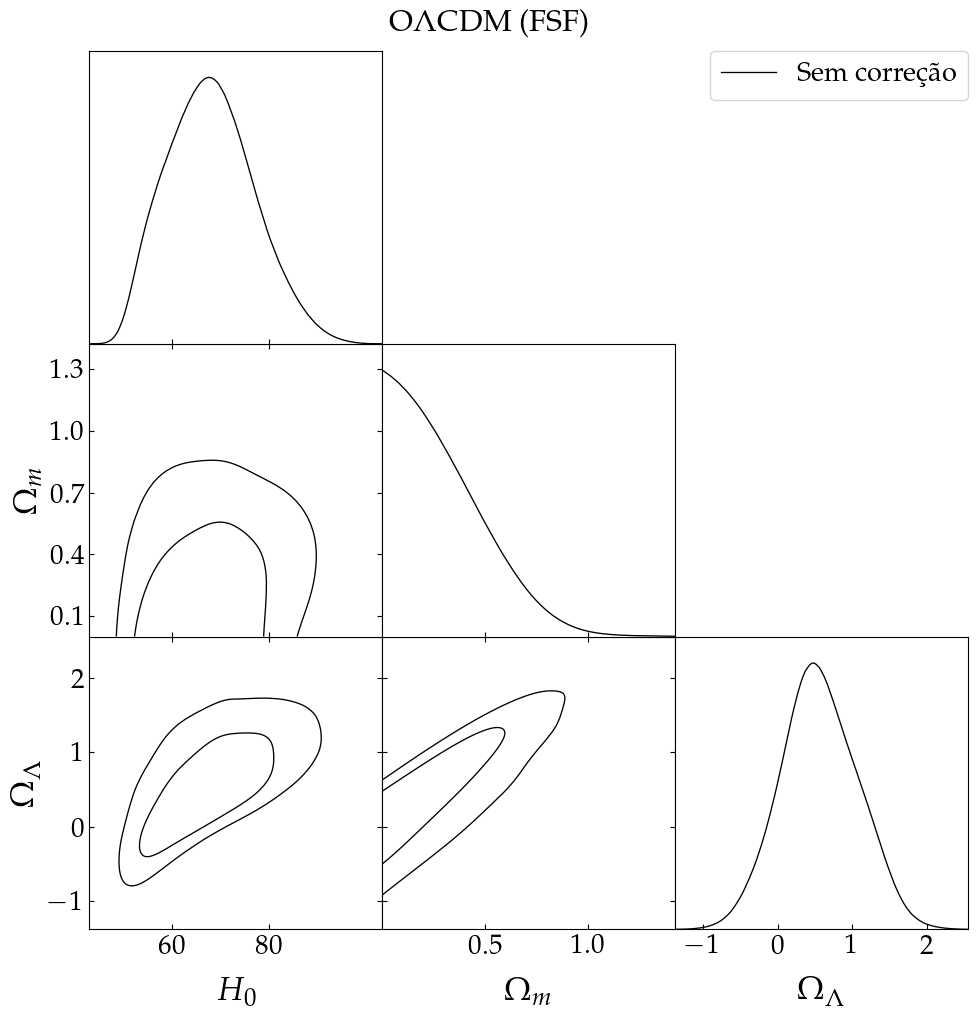

In [13]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC_FSF], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"O$\Lambda$CDM (FSF)", fontsize=22, y=1.02)
g.export('fig/OLCDM-FSF-no_f.pdf')
plt.show()

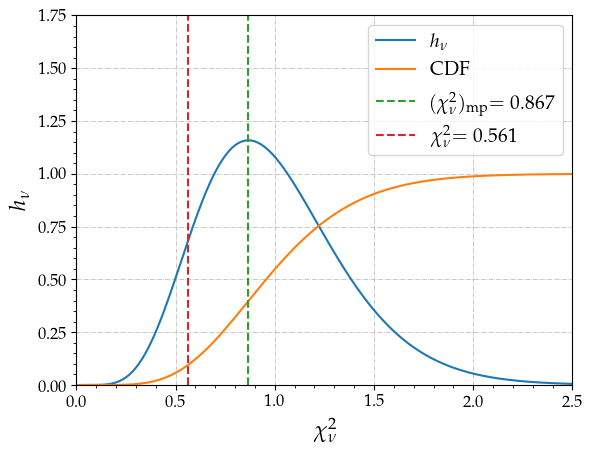

Probabilidade = 9.380162881359986%
chi2v = 0.560810518174037
chi2v mais provável = 0.8666666666666667


In [19]:
chi2mC = chi2Hz(free_par(best_par(samplesHzC), freef=False, flat=False), met='FSF')
chivCperc, errF = quad(chiDist, 0, chi2mC/(ndata_FSF-len(par_HzC)), args=(ndata_FSF-len(par_HzC)))
plotChiDist(chi2mC, len(par_HzC), ndata_FSF, name='OLCDM-FSF-chi-no_f')
print(f'Probabilidade = {chivCperc*100}%')
print(f'chi2v = {chi2mC/(ndata_FSF-len(par_HzC))}')
print(f'chi2v mais provável = {1 - 2/(ndata_FSF-len(par_HzC))}')

### OLCDM com correção

In [20]:
par_HzCF = [69.1929957609451,0.2480895086492853, 0.6862431649000225, .9]
ndimCF = len(par_HzCF)
prefixCF = 'OLcdmHz32Cov'
parlabelsCF = ["H_0","\\Omega_m", "\\Omega_\\Lambda", "f"]
parlabtexCF = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$", "$f$"]
parnamesCF = ['H0','wm','wl', 'f']

resultHzCF = find_bestfit(lnprobHz, par_HzCF, parnamesCF, freef=True, flat=False, met='FSF')
par_HzCF = resultHzCF['x']

Maximum likelihood result:
H0  =  66.96911531878101
wm  =  9.701021789054196e-10
wl  =  0.09817615275768432
f  =  0.6416579394123664
chi2min = 2.0250858441823336
Total time: 0.031 seg


/home/nirk/miniforge3/envs/cosmo_env/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/home/nirk/miniforge3/envs/cosmo_env/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


In [21]:
samplerHzCF = run_emcee(par_HzCF, 100, lnprobHz, True, False, 'FSF', 2.0, nstepHz)

  0%|                                                  | 0/5000 [00:00<?, ?it/s]/home/nirk/miniforge3/envs/cosmo_env/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████████████████████████████████| 5000/5000 [00:27<00:00, 181.21it/s]

Acceptance fraction: [0.553  0.5508 0.5534 0.5402 0.5144 0.544  0.5372 0.5436 0.5528 0.574
 0.5494 0.5406 0.5418 0.538  0.5628 0.5348 0.534  0.5432 0.5368 0.5412
 0.5304 0.532  0.5284 0.5428 0.538  0.5394 0.539  0.538  0.5472 0.5538
 0.5524 0.5358 0.535  0.5492 0.5538 0.5588 0.548  0.5522 0.5426 0.5286
 0.534  0.5682 0.5576 0.5572 0.5488 0.5406 0.5598 0.5416 0.5714 0.5698
 0.5466 0.5472 0.562  0.5534 0.5436 0.5512 0.5358 0.5312 0.5468 0.5406
 0.5446 0.543  0.546  0.5242 0.55   0.5462 0.5206 0.546  0.5468 0.5442
 0.5408 0.5258 0.556  0.5162 0.5632 0.5376 0.5472 0.5262 0.5474 0.5426
 0.5498 0.5492 0.5414 0.5514 0.5492 0.5462 0.5446 0.5184 0.535  0.5346
 0.554  0.5362 0.5582 0.5716 0.5586 0.5504 0.5358 0.5462 0.5632 0.5458]
Minimum acceptance: 0.5144
Maximum acceptance: 0.574


In [22]:
tauHzCF = samplerHzCF.get_autocorr_time()
print(tauHzCF)

tauHzmaxCF = np.amax(tauHzCF)
r = nstepHz/tauHzmaxCF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[56.50056812 62.82734338 62.51493205 54.92105611]
79.58318354926939
Convergiu! :)


In [23]:
samplesHzCF = burninthin(samplerHzCF, 100)

(9600, 4)


In [24]:
MC_result(samplesHzCF, par_HzCF, parnamesCF)

MCMC result:
H0 = 68.22804 +7.27963 +15.09002 -7.28377 -14.58051 (median: 68.08603, ml: 66.96912)
wm = 0.23216 +0.18003 +0.44969 -0.17583 -0.22426 (median: 0.19372, ml: 0.00000)
wl = 0.48289 +0.42719 +0.92049 -0.40391 -0.81551 (median: 0.45097, ml: 0.09818)
f = 0.77181 +0.15046 +0.38505 -0.15033 -0.24142 (median: 0.74667, ml: 0.64166)


In [31]:
gsamplesHzCF_FSF = MCSamples(samples=samplesHzCF, names=parnamesCF, labels=parlabelsCF, ranges={'wm':(0, None)})
gsamplesHzCF_FSF.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


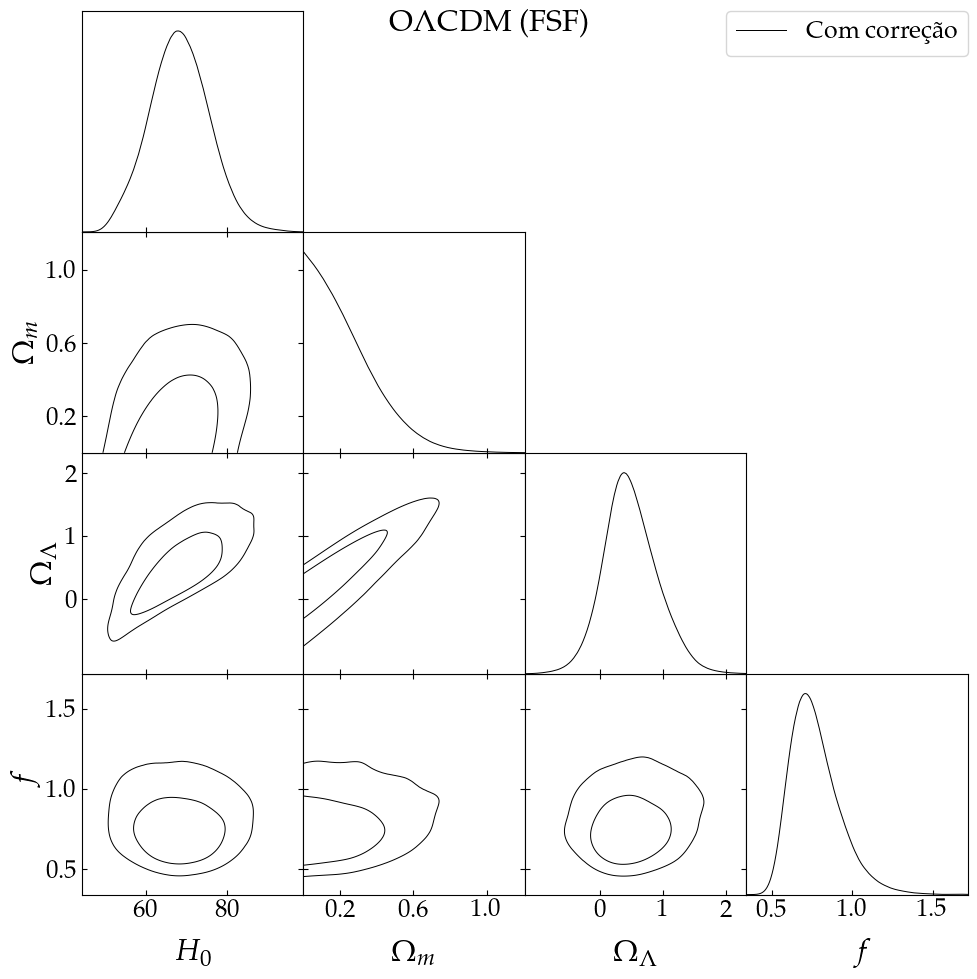

In [32]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzCF_FSF], filled=False, legend_labels=['Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM (FSF)", fontsize=22)
g.export('fig/OLCDM-FSF-f.pdf')
plt.show()

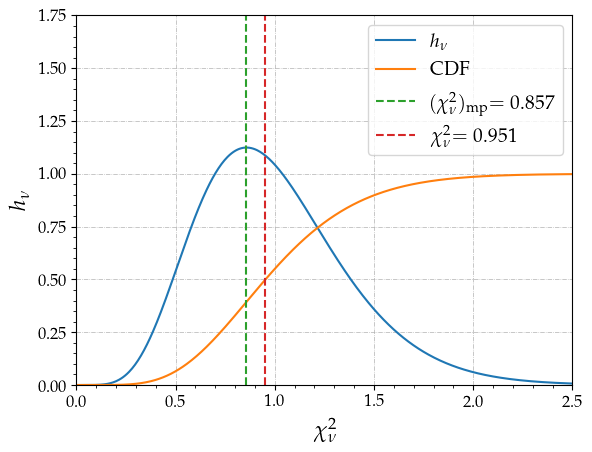

Probabilidade = 49.85536957293344%
chi2v = 0.9514740294088028
chi2v mais provável = 0.8571428571428572


In [28]:
chi2CF=chi2Hz(free_par(best_par(samplesHzCF), freef=True, flat=False), met='FSF')
plotChiDist(chi2CF, len(par_HzCF), ndata_FSF, name='OLCDM-FSF-chi-f')
chivCFperc, errF = quad(chiDist, 0, chi2CF/(ndata_FSF-len(par_HzCF)), args=(ndata_FSF-len(par_HzCF)))
print(f'Probabilidade = {chivCFperc*100}%')
print(f'chi2v = {chi2CF/(ndata_FSF-len(par_HzCF))}')
print(f'chi2v mais provável = {1 - 2/(ndata_FSF-len(par_HzCF))}')

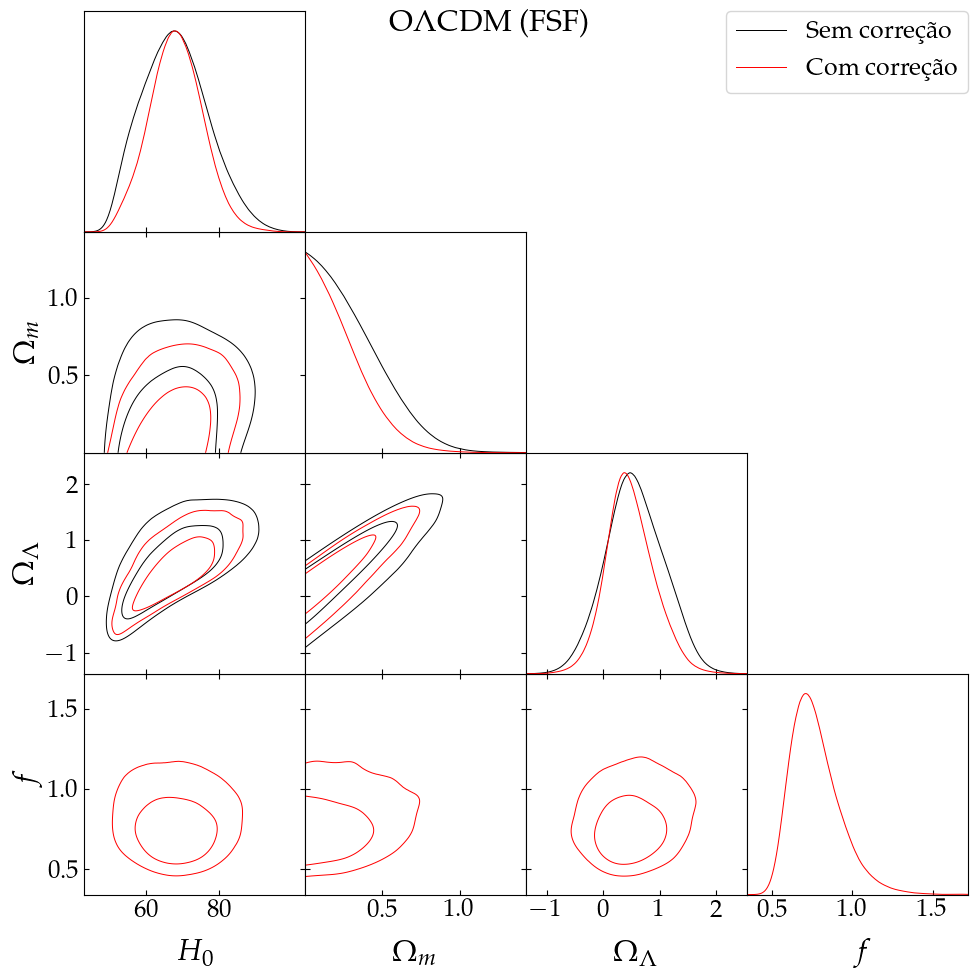

In [33]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC_FSF, gsamplesHzCF_FSF], ['H0', 'wm', 'wl', 'f'], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM (FSF)", fontsize=22)
g.export('fig/OLCDM-FSF.pdf')
plt.show()

### FLCDM sem correção

In [34]:
par_HzF = [69.1929957609451, 0.2480895086492853]
ndimF = len(par_HzF)
prefixF = 'FlatLcdmHz32Cov'
parlabelsF = ["H_0","\\Omega_m"]
parlabtexF = ["$H_0$","$\\Omega_m$"]
parnamesF = ['H0','wm']

resultHzF = find_bestfit(lnprobHz, par_HzF, parnamesF, freef=False, flat=True, met='FSF')
par_mlHzF = resultHzF['x']

Maximum likelihood result:
H0  =  71.9908135537291
wm  =  0.27937526123787587
chi2min = 7.9221009479208035
Total time: 0.007 seg


In [35]:
samplerHzF = run_emcee(par_HzF, 100, lnprobHz, False, True, 'FSF', 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:30<00:00, 165.50it/s]

Acceptance fraction: [0.7006 0.7122 0.6952 0.7014 0.7196 0.7076 0.696  0.7106 0.7108 0.7134
 0.704  0.7092 0.7008 0.7044 0.7056 0.7184 0.7168 0.7052 0.706  0.6962
 0.7142 0.7172 0.7046 0.699  0.7094 0.7228 0.7016 0.7076 0.712  0.7166
 0.703  0.7056 0.707  0.7156 0.7126 0.7056 0.707  0.7148 0.7012 0.6998
 0.6982 0.7082 0.7174 0.7048 0.716  0.7158 0.7054 0.7182 0.721  0.723
 0.7036 0.7036 0.7066 0.7104 0.6988 0.7066 0.7192 0.6932 0.7092 0.7102
 0.691  0.7076 0.7102 0.7056 0.708  0.7158 0.7096 0.6964 0.7132 0.715
 0.713  0.7072 0.7128 0.7052 0.7026 0.7106 0.7192 0.7036 0.7076 0.7178
 0.6982 0.7142 0.7124 0.705  0.6978 0.7086 0.702  0.699  0.7046 0.703
 0.7082 0.6936 0.7146 0.7194 0.71   0.6986 0.7092 0.7016 0.7054 0.7038]
Minimum acceptance: 0.691
Maximum acceptance: 0.723


In [36]:
tauHzF = samplerHzF.get_autocorr_time()
print(tauHzF)

tauHzmaxF = np.amax(tauHzF)
r = nstepHz/tauHzmaxF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[34.31277252 34.33690119]
145.61593580117997
Convergiu! :)


In [37]:
samplesHzF = burninthin(samplerHzF, tauHzF)

(29000, 2)


In [38]:
MC_result(samplesHzF, par_HzF, parnamesF)

MCMC result:
H0 = 70.10869 +8.04326 +16.07986 -8.20055 -15.81833 (median: 70.07208, ml: 69.19300)
wm = 0.31590 +0.09453 +0.25166 -0.09447 -0.15274 (median: 0.30002, ml: 0.24809)


In [39]:
gsamplesHzF_FSF = MCSamples(samples=samplesHzF, names=parnamesF, labels=parlabelsF, ranges={'wm':(0, None)})
gsamplesHzF_FSF.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


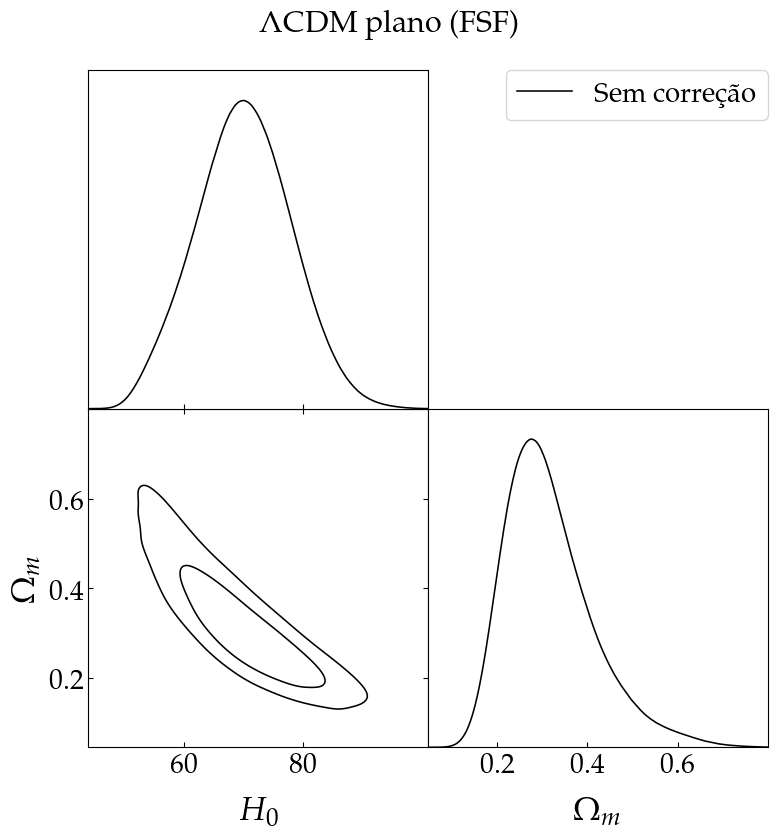

In [51]:
g = plots.getSubplotPlotter(width_inch=8)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF_FSF], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"$\Lambda$CDM plano (FSF)", fontsize=22, y=1.05)
plt.show()
g.export('fig/FLCDM-FSF-no_f.pdf')

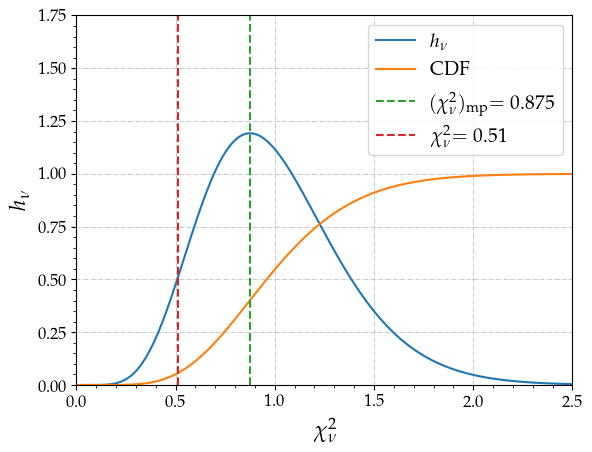

Probabilidade = 5.597893616167518%
chi2v = 0.5098783815058834
chi2v mais provável = 0.875


In [44]:
chi2F=chi2Hz(free_par(best_par(samplesHzF), freef=False, flat=True), met='FSF')
plotChiDist(chi2F, len(par_HzF), ndata_FSF, name='FLCDM-FSF-chi-no_f')
chivFperc, errF = quad(chiDist, 0, chi2F/(ndata_FSF-len(par_HzF)), args=(ndata_FSF-len(par_HzF)))
print(f'Probabilidade = {chivFperc*100}%')
print(f'chi2v = {chi2F/(ndata_FSF-len(par_HzF))}')
print(f'chi2v mais provável = {1 - 2/(ndata_FSF-len(par_HzF))}')

### FLCDM com correção

In [45]:
par_HzFf = [69.1929957609451,0.2480895086492853, .9]
ndimFf = len(par_HzFf)
prefixFf = 'LcdmHz32CovCorr'
parlabelsFf = ['H_0','\\Omega_m', 'f']
parlabtexFf = ['$H_0$','$\\Omega_m$', '$f$']
parnamesFf = ['H0','wm', 'f']

resultHzFf = find_bestfit(lnprobHz, par_HzFf, parnamesFf, freef=True, flat=True, met='FSF')
par_mlHzFf = resultHzFf['x']

Maximum likelihood result:
H0  =  71.99081030654085
wm  =  0.2793752863679682
f  =  0.663412915518913
chi2min = 3.227124311172961
Total time: 0.015 seg


In [46]:
samplerHzFf = run_emcee(par_HzFf, 100, lnprobHz, True, True, 'FSF', 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:29<00:00, 166.68it/s]

Acceptance fraction: [0.6338 0.6396 0.628  0.6464 0.6402 0.6302 0.6326 0.6296 0.6354 0.6366
 0.624  0.6264 0.6266 0.629  0.637  0.6414 0.6436 0.631  0.6354 0.6248
 0.6392 0.646  0.6304 0.6274 0.6514 0.6296 0.6286 0.631  0.641  0.6392
 0.6302 0.63   0.6444 0.6386 0.6482 0.6374 0.6332 0.6362 0.632  0.6256
 0.6352 0.6348 0.627  0.627  0.6396 0.6436 0.6264 0.637  0.6544 0.6376
 0.6316 0.6362 0.6452 0.634  0.635  0.6338 0.6308 0.6162 0.6228 0.6382
 0.6152 0.6274 0.635  0.6354 0.6406 0.6494 0.6418 0.621  0.6256 0.6278
 0.6342 0.6202 0.6294 0.6256 0.6432 0.6346 0.6354 0.6316 0.6242 0.637
 0.6368 0.6406 0.6438 0.6418 0.623  0.6406 0.6296 0.6254 0.6246 0.6284
 0.637  0.6324 0.6418 0.6492 0.6404 0.6412 0.6436 0.636  0.627  0.622 ]
Minimum acceptance: 0.6152
Maximum acceptance: 0.6544


In [47]:
tauHzFf = samplerHzFf.get_autocorr_time()
print(tauHzFf)

tauHzmaxFf = np.amax(tauHzFf)
r = nstepHz/tauHzmaxFf
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[40.93168051 41.03224353 41.43647794]
120.66662634134873
Convergiu! :)


In [48]:
samplesHzFf = burninthin(samplerHzFf, tauHzFf)

(24500, 3)


In [49]:
MC_result(samplesHzFf, par_mlHzFf, parnamesFf)

MCMC result:
H0 = 70.85518 +6.12929 +12.35600 -6.09713 -13.35139 (median: 70.94044, ml: 71.99081)
wm = 0.30113 +0.06734 +0.18738 -0.06866 -0.11683 (median: 0.29068, ml: 0.27938)
f = 0.76584 +0.14184 +0.37045 -0.14318 -0.23083 (median: 0.74246, ml: 0.66341)


In [50]:
gsamplesHzFf_FSF = MCSamples(samples=samplesHzFf, names=parnamesFf, labels=parlabelsFf, ranges={'wm':(0, None)})
gsamplesHzFf_FSF.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


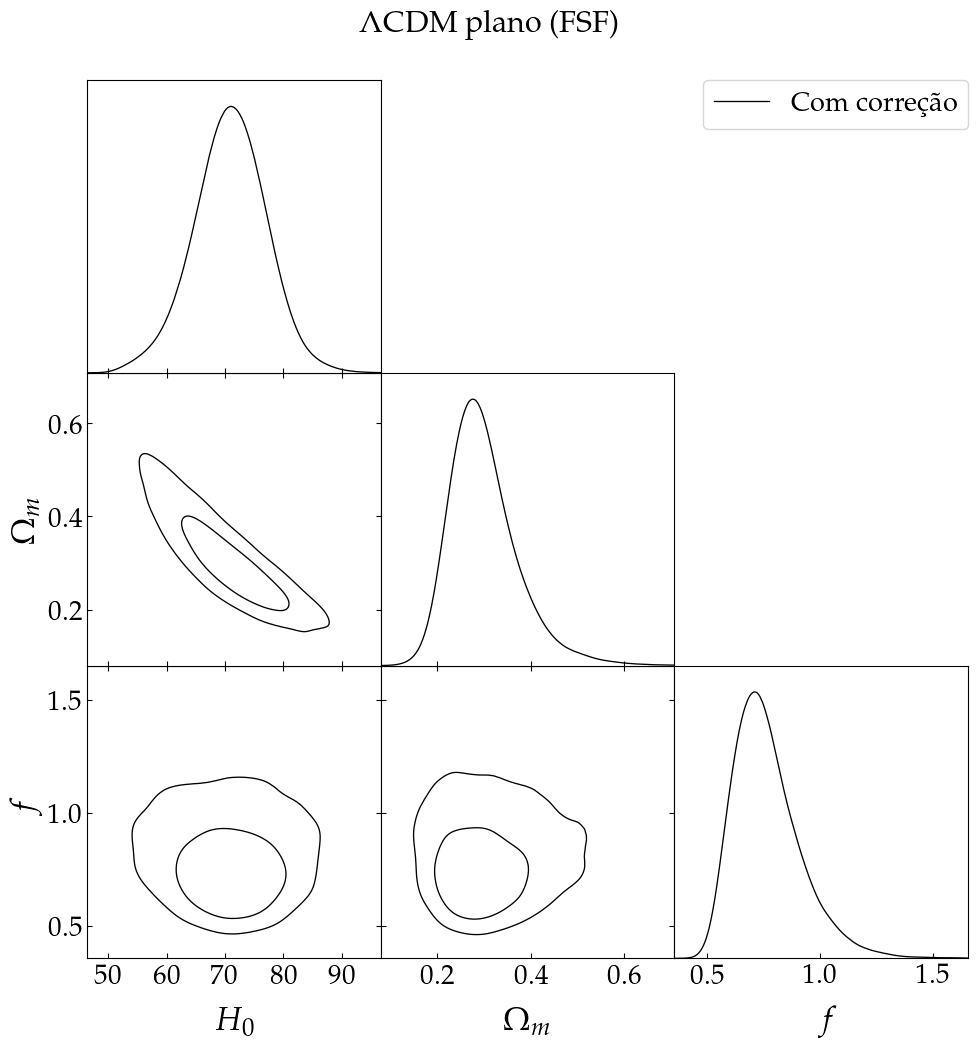

In [52]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzFf_FSF], filled=False, legend_labels=['Com correção'])
g.fig.suptitle(r"$\Lambda$CDM plano (FSF)", fontsize=22, y=1.05)
g.export('fig/FLCDM-FSF-f.pdf')
plt.show()

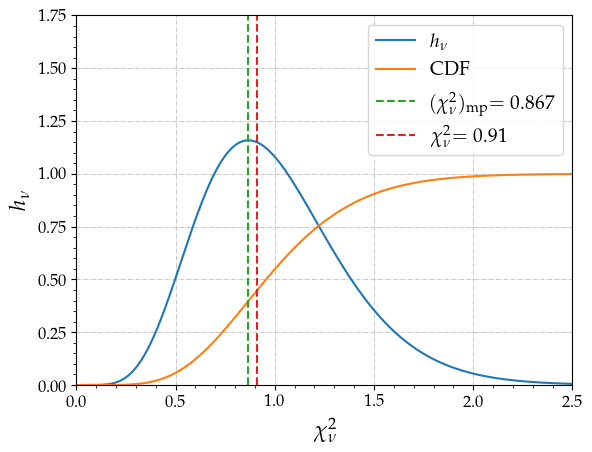

Probabilidade = 44.83225237602182%
chi2v = 0.9104739499297948
chi2v mais provável = 0.8666666666666667


In [53]:
chi2Ff=chi2Hz(free_par(best_par(samplesHzFf), freef=True, flat=True), met='FSF')
plotChiDist(chi2Ff, len(par_HzFf), ndata_FSF, name='FLCDM-FSF-chi-f')
chivFfperc, errF = quad(chiDist, 0, chi2Ff/(ndata_FSF-len(par_HzFf)), args=(ndata_FSF-len(par_HzFf)))
print(f'Probabilidade = {chivFfperc*100}%')
print(f'chi2v = {chi2Ff/(ndata_FSF-len(par_HzFf))}')
print(f'chi2v mais provável = {1 - 2/(ndata_FSF-len(par_HzFf))}')

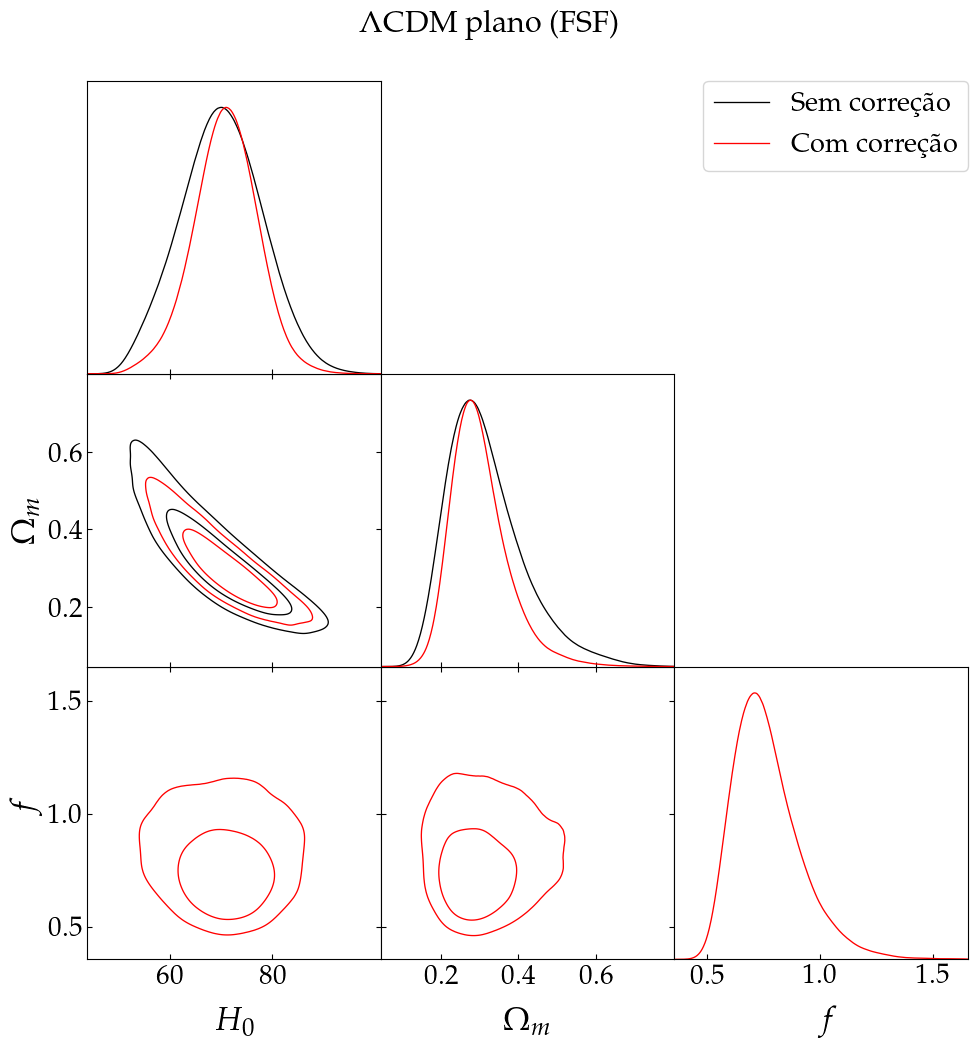

In [54]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF_FSF, gsamplesHzFf_FSF], ['H0', 'wm', 'f'], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"$\Lambda$CDM plano (FSF)", fontsize=22, y=1.05)
g.export('fig/FLCDM-FSF.pdf')
plt.show()

# Análise D4000

In [55]:
ndata_d4000 = len(z_d4000)
cov_mat_diag = np.zeros((ndata_d4000, ndata_d4000), dtype='float64')

for i in range(ndata_d4000):
    cov_mat_diag[i,i] = sH_d4000[i]**2

imf_intp = np.interp(z_d4000, zmod, imf)/100
spsooo_intp = np.interp(z_d4000, zmod, spsooo)/100

cov_mat_imf = np.zeros((ndata_d4000, ndata_d4000), dtype='float64')
cov_mat_spsooo = np.zeros((ndata_d4000, ndata_d4000), dtype='float64')

for i in range(ndata_d4000):
    for j in range(ndata_d4000):
        cov_mat_imf[i,j] = h_d4000[i] * imf_intp[i] * h_d4000[j] * imf_intp[j]
        cov_mat_spsooo[i,j] = h_d4000[i] * spsooo_intp[i] * h_d4000[j] * spsooo_intp[j]

cov_mat = cov_mat_imf + cov_mat_spsooo + cov_mat_diag
inv_cov = linalg.inv(cov_mat)

### OLCDM sem correção

In [56]:
par_HzC = [69.1929957609451,0.2480895086492853, 0.6862431649000225]
ndimC = len(par_HzC)
prefixC = 'LcdmHz32Cov'
parlabelsC = ["H_0","\\Omega_m", "\\Omega_\\Lambda"]
parlabtexC = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$"]
parnamesC = ['H0','wm','wl']

resultHzC = find_bestfit(lnprobHz, par_HzC, parnamesC, freef=False, flat=False, met='D4000')
par_HzC = resultHzC['x']

Maximum likelihood result:
H0  =  69.85073783056532
wm  =  0.5696513015639394
wl  =  1.0431525743069165
chi2min = 5.597174444126691
Total time: 0.009 seg


In [57]:
samplerHzC = run_emcee(par_HzC, 100, lnprobHz, False, False, 'D4000', 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:28<00:00, 172.80it/s]

Acceptance fraction: [0.6298 0.6258 0.6188 0.641  0.6156 0.633  0.6274 0.6212 0.6342 0.6386
 0.6148 0.624  0.6258 0.6366 0.6332 0.632  0.6418 0.6262 0.6246 0.6226
 0.6408 0.6292 0.63   0.6292 0.6374 0.6518 0.6376 0.6328 0.6382 0.6312
 0.626  0.6284 0.629  0.6406 0.6338 0.627  0.6346 0.6288 0.6168 0.6366
 0.6292 0.634  0.6328 0.6292 0.6392 0.64   0.6204 0.6438 0.6528 0.6298
 0.6182 0.6278 0.6334 0.6296 0.6308 0.6348 0.6326 0.6174 0.626  0.6336
 0.6082 0.6266 0.6392 0.6266 0.63   0.6424 0.6152 0.6108 0.6284 0.6326
 0.6262 0.6302 0.6272 0.6122 0.632  0.6238 0.6442 0.6214 0.6326 0.627
 0.6298 0.6284 0.6374 0.638  0.6232 0.6314 0.6258 0.62   0.6298 0.6286
 0.6292 0.6208 0.6388 0.6408 0.6322 0.6216 0.615  0.624  0.6258 0.628 ]
Minimum acceptance: 0.6082
Maximum acceptance: 0.6528


In [58]:
tauHzC = samplerHzC.get_autocorr_time()
print(tauHzC)

tauHzmaxC = np.amax(tauHzC)
r = nstepHz/tauHzmaxC
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[42.35542646 40.44013631 43.16352039]
115.83855893215363
Convergiu! :)


In [59]:
samplesHzC = burninthin(samplerHzC, 100)

(9600, 3)


In [60]:
MC_result(samplesHzC, par_HzC, parnamesC)

MCMC result:
H0 = 67.94654 +7.03898 +14.08773 -7.17443 -13.56631 (median: 67.91131, ml: 69.85074)
wm = 0.59635 +0.35042 +0.70443 -0.35823 -0.55521 (median: 0.57606, ml: 0.56965)
wl = 0.96135 +0.55553 +1.00773 -0.55677 -1.08025 (median: 0.98161, ml: 1.04315)


In [61]:
gsamplesHzC_D4000 = MCSamples(samples=samplesHzC, names=parnamesC, labels=parlabelsC, ranges={'wm':(0, None)})
gsamplesHzC_D4000.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


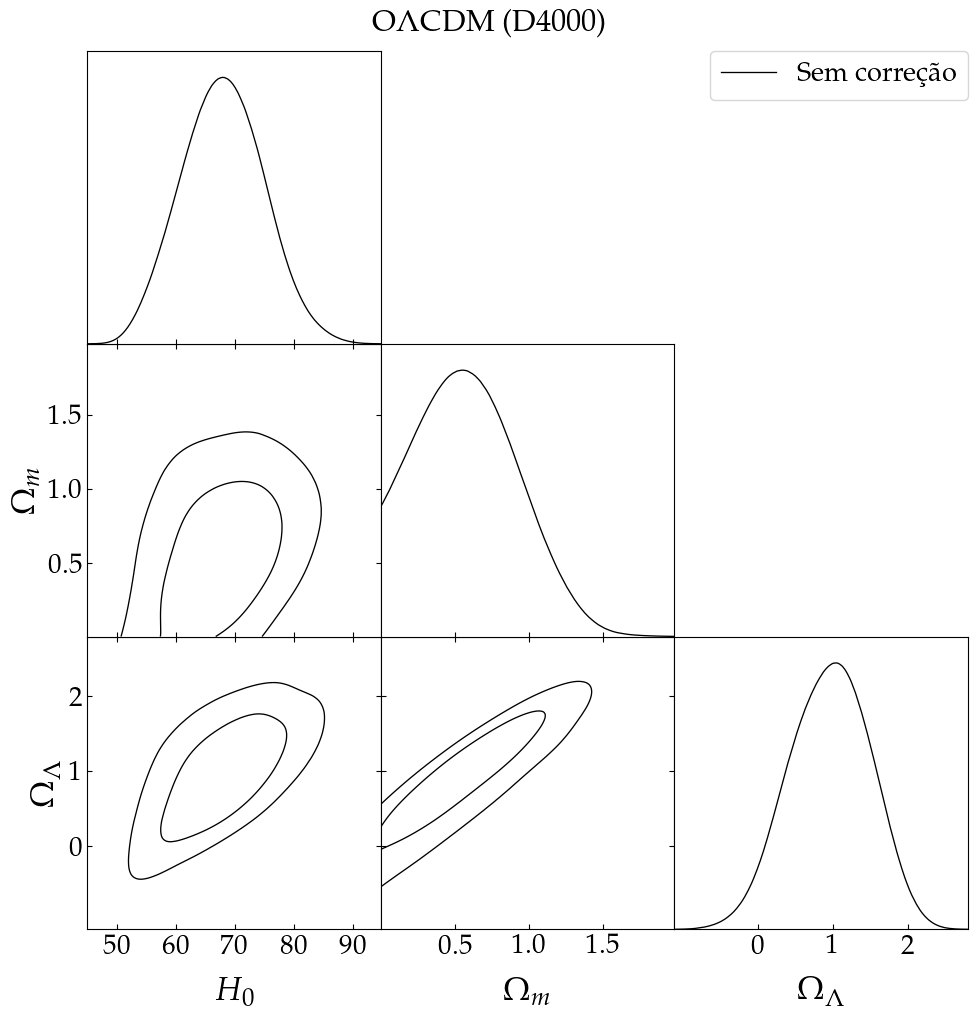

In [62]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC_D4000], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"O$\Lambda$CDM (D4000)", fontsize=22, y=1.02)
g.export('fig/OLCDM-D4000-no_f.pdf')
plt.show()

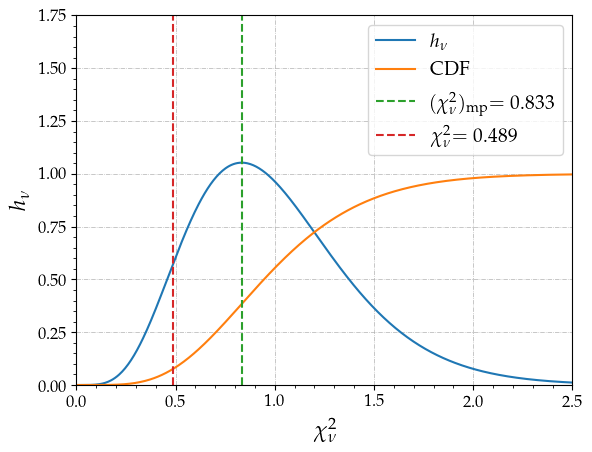

Probabilidade = 7.712478936914706%
chi2v = 0.4885048103697253
chi2v mais provável = 0.8333333333333334


In [63]:
chi2mC = chi2Hz(free_par(best_par(samplesHzC), freef=False, flat=False), met='D4000')
chivCperc, errF = quad(chiDist, 0, chi2mC/(ndata_d4000-len(par_HzC)), args=(ndata_d4000-len(par_HzC)))
plotChiDist(chi2mC, len(par_HzC), ndata_d4000, name='OLCDM-D4000-chi-no_f')
print(f'Probabilidade = {chivCperc*100}%')
print(f'chi2v = {chi2mC/(ndata_d4000-len(par_HzC))}')
print(f'chi2v mais provável = {1 - 2/(ndata_d4000-len(par_HzC))}')

### OLCDM com correção

In [64]:
par_HzCF = [69.1929957609451,0.2480895086492853, 0.6862431649000225, .9]
ndimCF = len(par_HzCF)
prefixCF = 'OLcdmHz32Cov'
parlabelsCF = ["H_0","\\Omega_m", "\\Omega_\\Lambda", "f"]
parlabtexCF = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$", "$f$"]
parnamesCF = ['H0','wm','wl', 'f']

resultHzCF = find_bestfit(lnprobHz, par_HzCF, parnamesCF, freef=True, flat=False, met='D4000')
par_HzCF = resultHzCF['x']

Maximum likelihood result:
H0  =  69.85074307461679
wm  =  0.5696514646663218
wl  =  1.0431529110743074
f  =  0.6108559246369668
chi2min = 0.21317558632095945
Total time: 0.012 seg


In [65]:
samplerHzCF = run_emcee(par_HzCF, 100, lnprobHz, True, False, 'D4000', 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:28<00:00, 175.63it/s]

Acceptance fraction: [0.5716 0.5754 0.5636 0.5692 0.5808 0.577  0.573  0.5776 0.584  0.5908
 0.5658 0.5842 0.5644 0.571  0.5896 0.579  0.5872 0.5954 0.5706 0.578
 0.5778 0.5702 0.5612 0.5798 0.5844 0.5718 0.5846 0.58   0.5734 0.5762
 0.5736 0.5758 0.579  0.5882 0.5884 0.5768 0.576  0.5716 0.5552 0.5686
 0.5714 0.5676 0.5784 0.5782 0.5672 0.5904 0.5788 0.578  0.5842 0.5776
 0.5806 0.5768 0.5666 0.5666 0.5842 0.586  0.5864 0.568  0.567  0.5782
 0.5574 0.571  0.6    0.5826 0.5894 0.5792 0.5766 0.5828 0.5718 0.5736
 0.5818 0.5698 0.5746 0.5846 0.5792 0.5694 0.575  0.572  0.5714 0.5736
 0.5782 0.5914 0.5872 0.5726 0.5668 0.5632 0.5768 0.5822 0.57   0.5728
 0.5758 0.5802 0.5778 0.5956 0.5784 0.5716 0.5748 0.5788 0.594  0.577 ]
Minimum acceptance: 0.5552
Maximum acceptance: 0.6


In [66]:
tauHzCF = samplerHzCF.get_autocorr_time()
print(tauHzCF)

tauHzmaxCF = np.amax(tauHzCF)
r = nstepHz/tauHzmaxCF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[46.43772931 50.41934846 49.25453261 48.92566972]
99.16827870357486
Convergiu! :)


In [67]:
samplesHzCF = burninthin(samplerHzCF, 100)

(9600, 4)


In [68]:
MC_result(samplesHzCF, par_HzCF, parnamesCF)

MCMC result:
H0 = 68.44455 +5.48757 +11.20031 -5.53226 -11.90934 (median: 68.56073, ml: 69.85074)
wm = 0.56381 +0.26839 +0.58681 -0.28752 -0.50516 (median: 0.55345, ml: 0.56965)
wl = 0.95743 +0.44469 +0.86617 -0.45464 -0.92827 (median: 0.97497, ml: 1.04315)
f = 0.75884 +0.16207 +0.42979 -0.16288 -0.25915 (median: 0.73097, ml: 0.61086)


In [69]:
gsamplesHzCF_D4000 = MCSamples(samples=samplesHzCF, names=parnamesCF, labels=parlabelsCF, ranges={'wm':(0, None)})
gsamplesHzCF_D4000.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


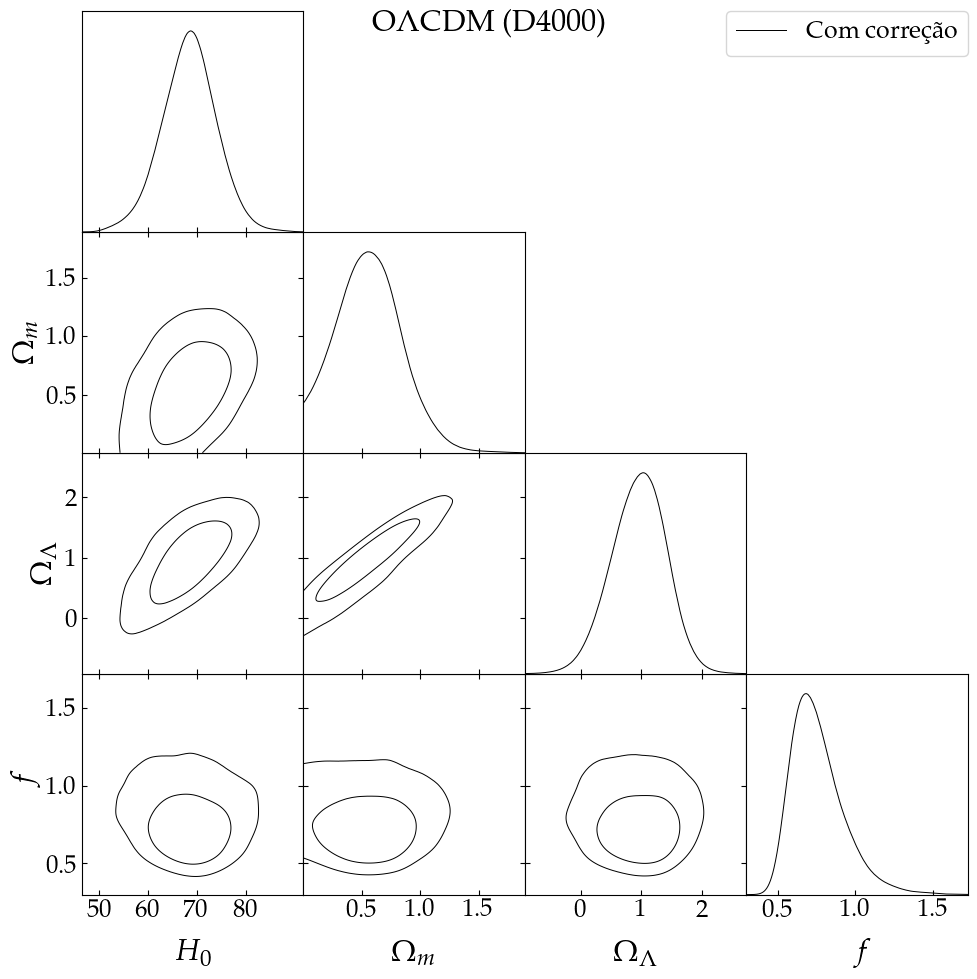

In [70]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzCF_D4000], filled=False, legend_labels=['Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM (D4000)", fontsize=22)
g.export('fig/OLCDM-D4000-f.pdf')
plt.show()

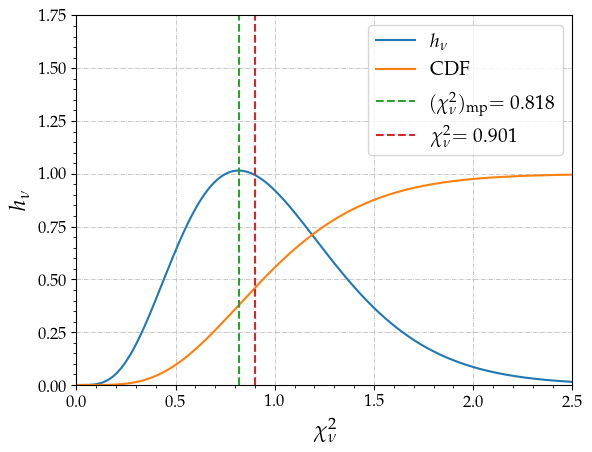

Probabilidade = 49.85536957293344%
chi2v = 0.9012805264522714
chi2v mais provável = 0.8181818181818181


In [72]:
chi2CF = chi2Hz(free_par(best_par(samplesHzCF), freef=True, flat=False), met='D4000')
chivCperc, errF = quad(chiDist, 0, chi2CF/(ndata_d4000-len(par_HzCF)), args=(ndata_d4000-len(par_HzCF)))
plotChiDist(chi2CF, len(par_HzCF), ndata_d4000, name='OLCDM-D4000-chi-f')
print(f'Probabilidade = {chivCFperc*100}%')
print(f'chi2v = {chi2CF/(ndata_d4000-len(par_HzCF))}')
print(f'chi2v mais provável = {1 - 2/(ndata_d4000-len(par_HzCF))}')

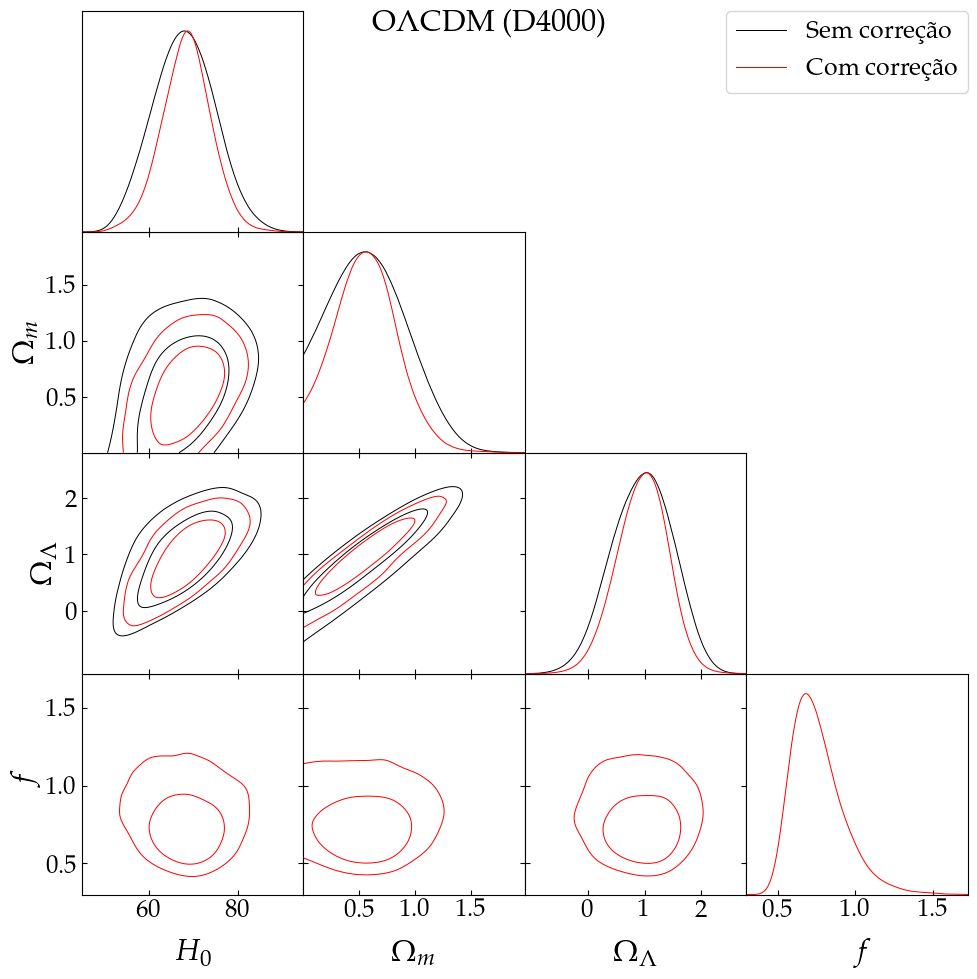

In [73]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC_D4000, gsamplesHzCF_D4000], ['H0', 'wm', 'wl', 'f'] ,filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM (D4000)", fontsize=22)
g.export('fig/OLCDM-D4000.pdf')
plt.show()

### FLCDM sem correção

In [74]:
par_HzF = [69.1929957609451, 0.2480895086492853]
ndimF = len(par_HzF)
prefixF = 'FlatLcdmHz32Cov'
parlabelsF = ["H_0","\\Omega_m"]
parlabtexF = ["$H_0$","$\\Omega_m$"]
parnamesF = ['H0','wm']

resultHzF = find_bestfit(lnprobHz, par_HzF, parnamesF, freef=False, flat=True, met='D4000')
par_mlHzF = resultHzF['x']

Maximum likelihood result:
H0  =  66.97014096044336
wm  =  0.33834532194786776
chi2min = 5.934088809026537
Total time: 0.010 seg


In [75]:
samplerHzF = run_emcee(par_HzF, 100, lnprobHz, False, True, 'D4000', 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:30<00:00, 166.35it/s]

Acceptance fraction: [0.7136 0.7238 0.7036 0.7232 0.707  0.7032 0.6988 0.7058 0.723  0.7118
 0.7104 0.7106 0.7006 0.7024 0.7164 0.7244 0.7244 0.7078 0.714  0.7118
 0.7106 0.7148 0.7104 0.7168 0.7206 0.7136 0.7092 0.7076 0.7062 0.7166
 0.7188 0.7078 0.72   0.7284 0.719  0.7098 0.7136 0.7122 0.6946 0.7056
 0.7016 0.7256 0.717  0.7132 0.7144 0.721  0.709  0.7202 0.7154 0.7132
 0.7132 0.712  0.7312 0.7078 0.7016 0.7162 0.7106 0.7064 0.7086 0.7104
 0.6942 0.7094 0.7276 0.704  0.726  0.7056 0.716  0.71   0.7104 0.7142
 0.718  0.712  0.7096 0.709  0.7128 0.7178 0.7178 0.7014 0.7018 0.7224
 0.7078 0.7188 0.726  0.714  0.72   0.7224 0.7046 0.715  0.7026 0.7076
 0.721  0.708  0.704  0.7148 0.7118 0.7122 0.7166 0.7068 0.7174 0.7024]
Minimum acceptance: 0.6942
Maximum acceptance: 0.7312


In [76]:
tauHzF = samplerHzF.get_autocorr_time()
print(tauHzF)

tauHzmaxF = np.amax(tauHzF)
r = nstepHz/tauHzmaxF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[31.87166853 33.72145281]
148.27356424486734
Convergiu! :)


In [77]:
samplesHzF = burninthin(samplerHzF, tauHzF)

(32800, 2)


In [78]:
MC_result(samplesHzF, par_HzF, parnamesF)

MCMC result:
H0 = 65.83189 +5.72259 +11.26889 -5.80527 -11.39527 (median: 65.88905, ml: 69.19300)
wm = 0.37071 +0.10513 +0.26173 -0.10460 -0.17793 (median: 0.35723, ml: 0.24809)


In [79]:
gsamplesHzF_D4000 = MCSamples(samples=samplesHzF, names=parnamesF, labels=parlabelsF, ranges={'wm':(0, None)})
gsamplesHzF_D4000.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


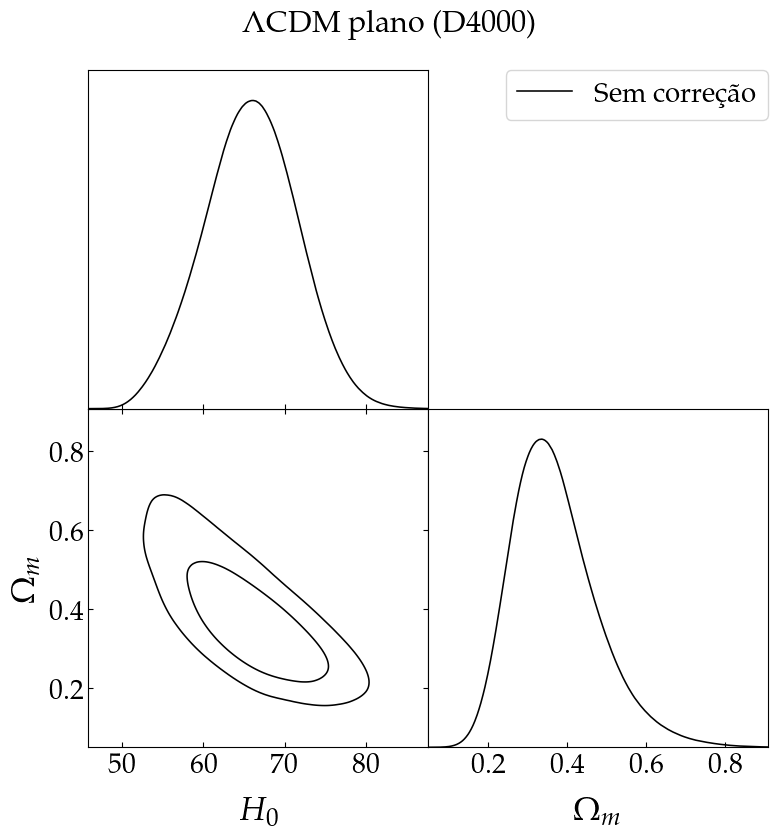

In [80]:
g = plots.getSubplotPlotter(width_inch=8)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF_D4000], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"$\Lambda$CDM plano (D4000)", fontsize=22, y=1.05)
g.export('fig/FLCDM-D4000-no_f.pdf')
plt.show()

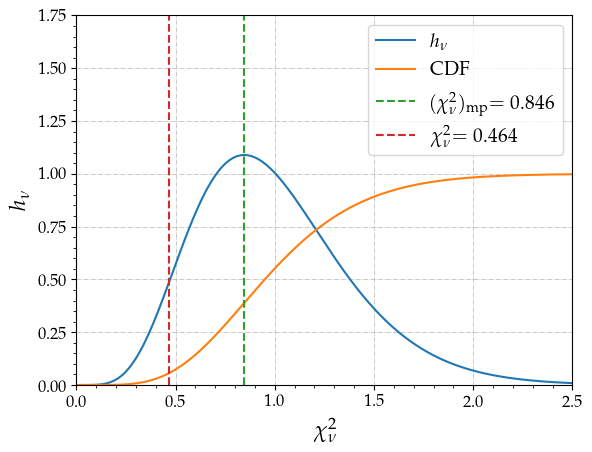

Probabilidade = 5.523606900646513%
chi2v = 0.46445131718281735
chi2v mais provável = 0.8461538461538461


In [85]:
chi2F=chi2Hz(free_par(best_par(samplesHzF), freef=False, flat=True), met='D4000')
plotChiDist(chi2F, len(par_HzF), ndata_d4000, name='FLCDM-D4000-chi-no_f')
chivFperc, errF = quad(chiDist, 0, chi2F/(ndata_d4000-len(par_HzF)), args=(ndata_d4000-len(par_HzF)))
print(f'Probabilidade = {chivFperc*100}%')
print(f'chi2v = {chi2F/(ndata_d4000-len(par_HzF))}')
print(f'chi2v mais provável = {1 - 2/(ndata_d4000-len(par_HzF))}')

### FLCDM com correção

In [86]:
par_HzFf = [69.1929957609451,0.2480895086492853, .9]
ndimFf = len(par_HzFf)
prefixFf = 'LcdmHz32CovCorr'
parlabelsFf = ['H_0','\\Omega_m', 'f']
parlabtexFf = ['$H_0$','$\\Omega_m$', '$f$']
parnamesFf = ['H0','wm', 'f']

resultHzFf = find_bestfit(lnprobHz, par_HzFf, parnamesFf, freef=True, flat=True, met='D4000')
par_mlHzFf = resultHzFf['x']

Maximum likelihood result:
H0  =  66.97014279498632
wm  =  0.33834530057497103
f  =  0.6289721054490949
chi2min = 1.0899493017950892
Total time: 0.011 seg


In [87]:
samplerHzFf = run_emcee(par_HzFf, 100, lnprobHz, True, True, 'D4000', 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:29<00:00, 167.27it/s]

Acceptance fraction: [0.63   0.642  0.6364 0.642  0.6352 0.6318 0.6356 0.6518 0.6488 0.6442
 0.633  0.6316 0.6346 0.6238 0.6266 0.6466 0.6482 0.6346 0.6406 0.6298
 0.6306 0.6402 0.6406 0.636  0.6388 0.651  0.6402 0.6338 0.6278 0.6458
 0.6412 0.6366 0.6412 0.6578 0.651  0.6324 0.641  0.6434 0.632  0.6318
 0.621  0.6354 0.6328 0.6398 0.638  0.649  0.6404 0.6342 0.6488 0.6258
 0.6482 0.6368 0.6408 0.6388 0.6274 0.6434 0.639  0.6312 0.633  0.6438
 0.6166 0.6398 0.646  0.641  0.6458 0.6352 0.637  0.6422 0.6338 0.6318
 0.6354 0.6254 0.6288 0.6294 0.6438 0.6372 0.6366 0.642  0.64   0.6386
 0.6318 0.635  0.6412 0.6422 0.6522 0.6366 0.6396 0.6258 0.6328 0.6276
 0.6394 0.6264 0.6368 0.6344 0.649  0.6404 0.6464 0.629  0.6368 0.6268]
Minimum acceptance: 0.6166
Maximum acceptance: 0.6578


In [88]:
tauHzFf = samplerHzFf.get_autocorr_time()
print(tauHzFf)

tauHzmaxFf = np.amax(tauHzFf)
r = nstepHz/tauHzmaxFf
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[40.24256422 40.01724436 40.25473243]
124.20899851204159
Convergiu! :)


In [89]:
samplesHzFf = burninthin(samplerHzFf, tauHzFf)

(24600, 3)


In [90]:
MC_result(samplesHzFf, par_mlHzFf, parnamesFf)

MCMC result:
H0 = 66.35168 +4.17342 +8.84663 -4.20142 -9.21634 (median: 66.44961, ml: 66.97014)
wm = 0.35684 +0.07450 +0.19094 -0.07561 -0.13700 (median: 0.34831, ml: 0.33835)
f = 0.74731 +0.15130 +0.41574 -0.15281 -0.24777 (median: 0.72008, ml: 0.62897)


In [91]:
gsamplesHzFf_D4000 = MCSamples(samples=samplesHzFf, names=parnamesFf, labels=parlabelsFf, ranges={'wm':(0, None)})
gsamplesHzFf_D4000.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


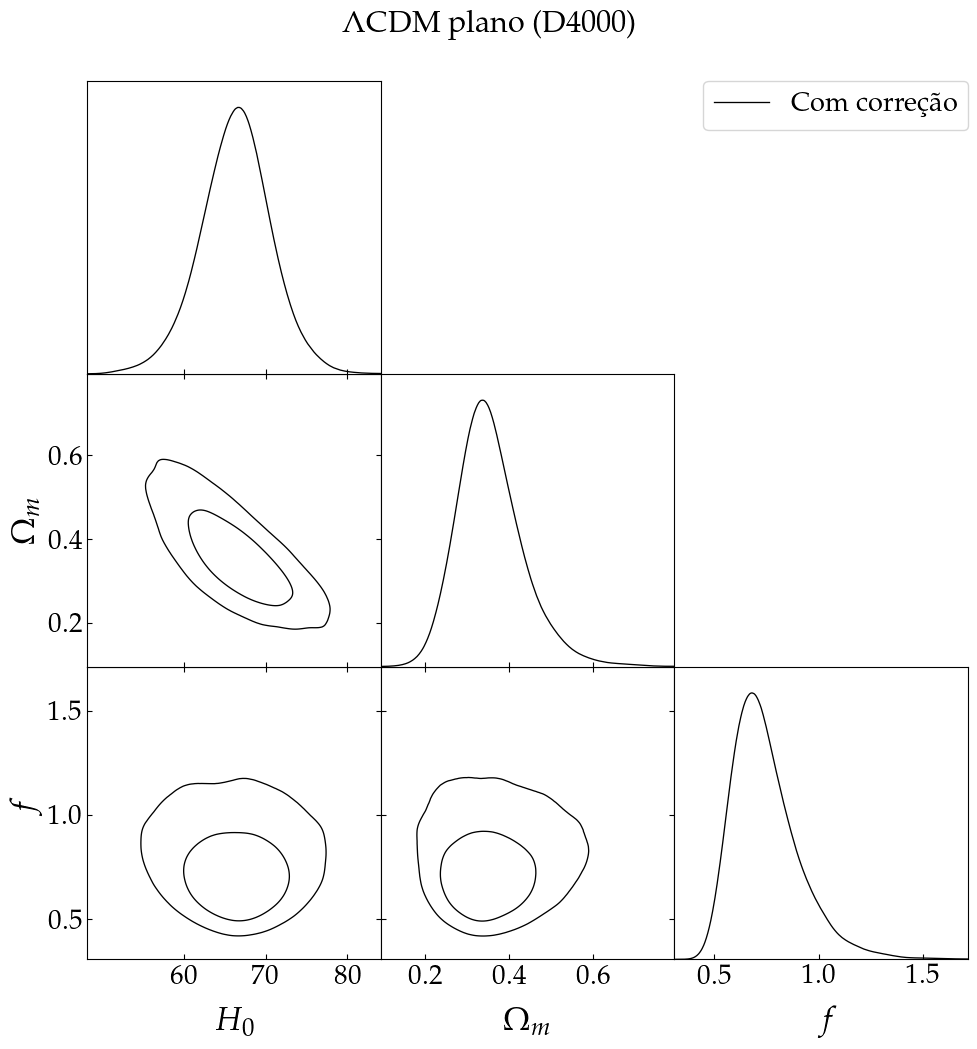

In [92]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzFf_D4000], filled=False, legend_labels=['Com correção'])
g.fig.suptitle(r"$\Lambda$CDM plano (D4000)", fontsize=22, y=1.05)
g.export('fig/FLCDM-D4000-f.pdf')
plt.show()

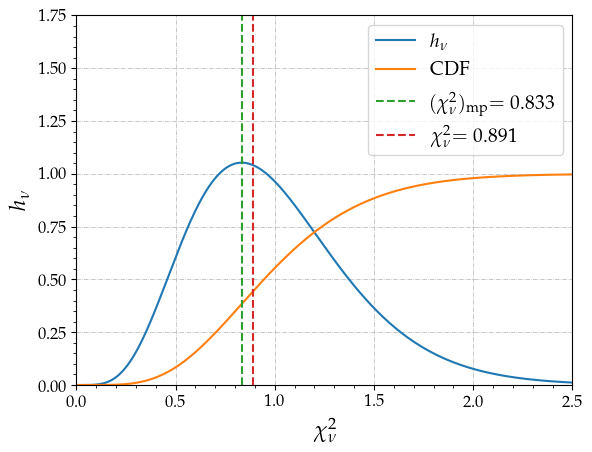

Probabilidade = 44.43050949927037%
chi2v = 0.8907958012779812
chi2v mais provável = 0.8333333333333334


In [93]:
chi2Ff=chi2Hz(free_par(best_par(samplesHzFf), freef=True, flat=True), met='D4000')
plotChiDist(chi2Ff, len(par_HzFf), ndata_d4000, name='FLCDM-D4000-chi-f')
chivFfperc, errF = quad(chiDist, 0, chi2Ff/(ndata_d4000-len(par_HzFf)), args=(ndata_d4000-len(par_HzFf)))
print(f'Probabilidade = {chivFfperc*100}%')
print(f'chi2v = {chi2Ff/(ndata_d4000-len(par_HzFf))}')
print(f'chi2v mais provável = {1 - 2/(ndata_d4000-len(par_HzFf))}')

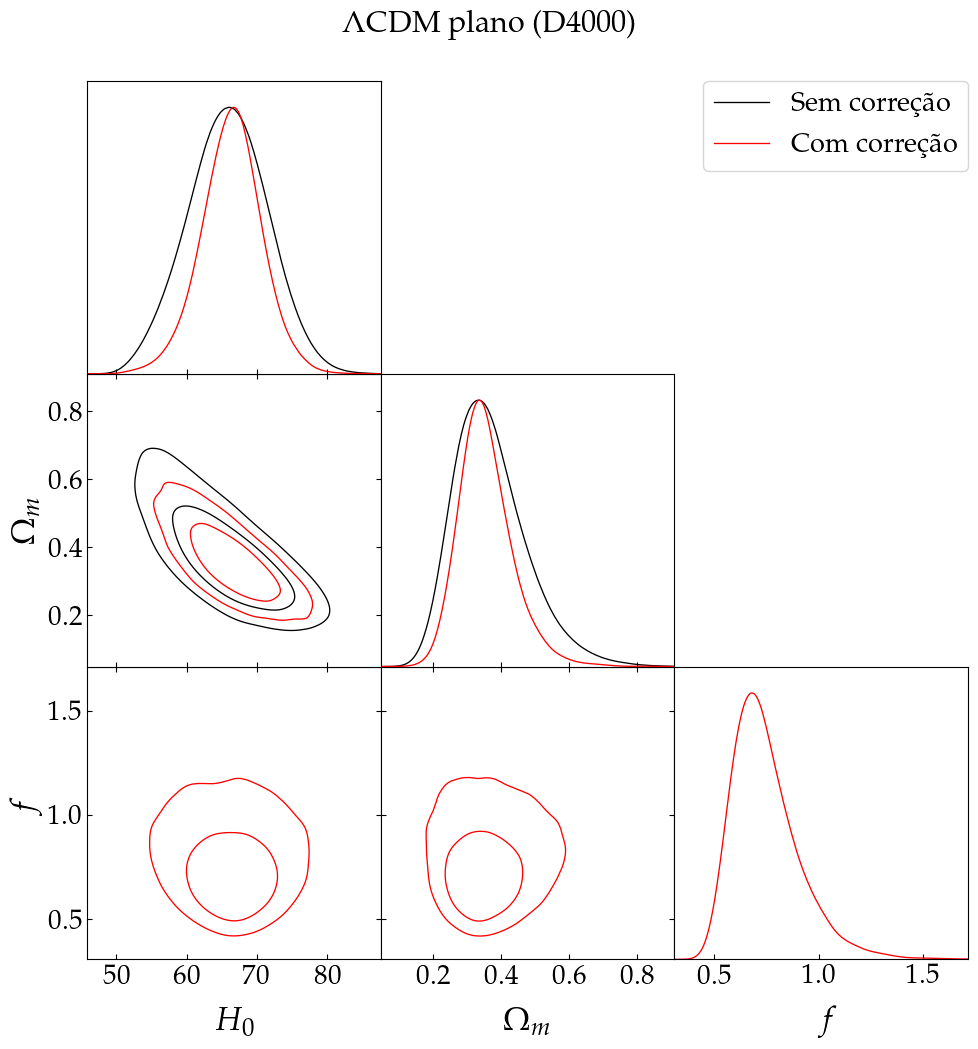

In [94]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF_D4000, gsamplesHzFf_D4000], ['H0', 'wm', 'f'], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"$\Lambda$CDM plano (D4000)", fontsize=22, y=1.05)
g.export('fig/FLCDM-D4000.pdf')
plt.show()

# Resultados
## OLCDM
### Sem correção

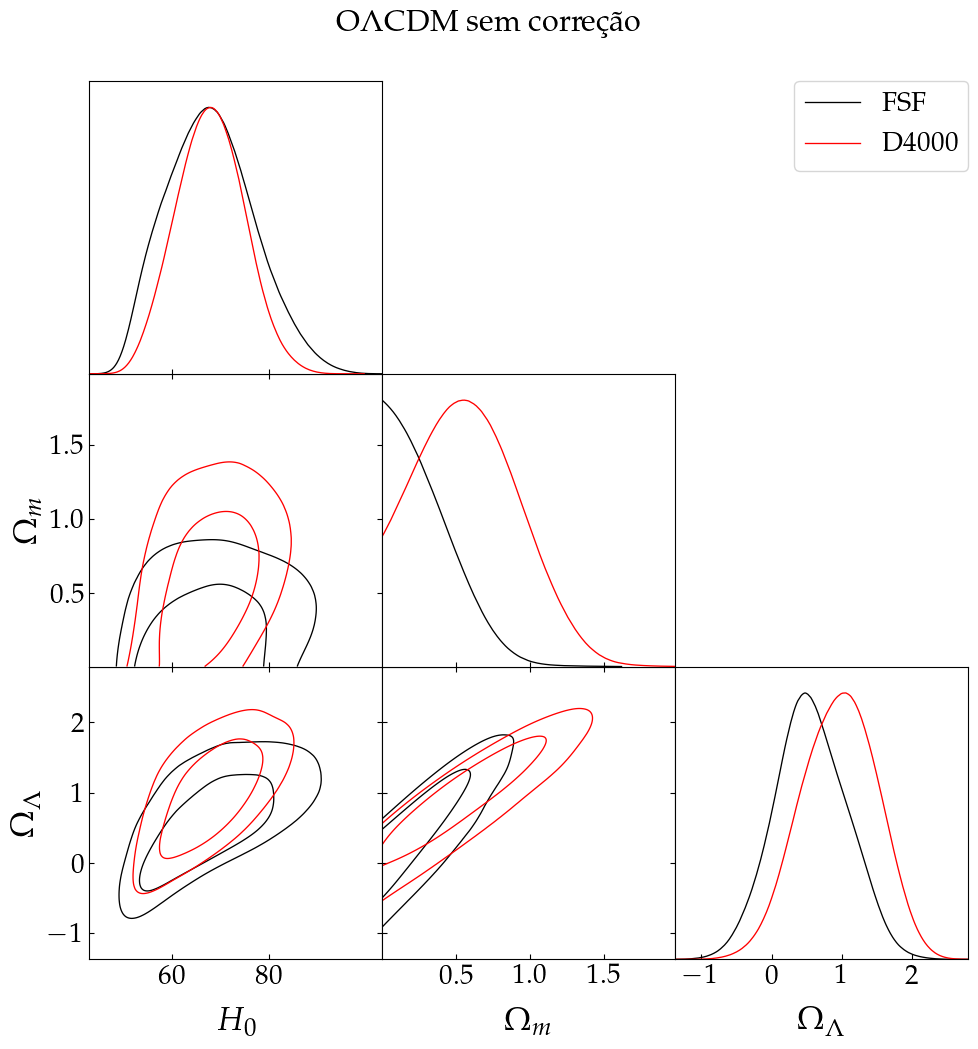

In [97]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC_FSF, gsamplesHzC_D4000], ['H0', 'wm', 'wl'], filled=False, legend_labels=['FSF', 'D4000'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM sem correção", fontsize=22, y=1.05)
g.export('fig/OLCDM-FSF-D4000-no_f.pdf')
plt.show()

In [101]:
print('FSF')
print('H0 = 67.97040 +9.13960 +19.17122 -9.55772 -15.97408 (median: 67.65043, ml: 66.96881)')
print('wm = 0.30098 +0.23227 +0.52686 -0.22359 -0.29020 (median: 0.25998, ml: 0.00000)')
print('wl = 0.56272 +0.54089 +1.03118 -0.51638 -1.02266 (median: 0.54258, ml: 0.09815)')
print('\nD4000')
print('H0 = 67.94654 +7.03898 +14.08773 -7.17443 -13.56631 (median: 67.91131, ml: 69.85074)')
print('wm = 0.59635 +0.35042 +0.70443 -0.35823 -0.55521 (median: 0.57606, ml: 0.56965)')
print('wl = 0.96135 +0.55553 +1.00773 -0.55677 -1.08025 (median: 0.98161, ml: 1.04315)')

FSF
H0 = 67.97040 +9.13960 +19.17122 -9.55772 -15.97408 (median: 67.65043, ml: 66.96881)
wm = 0.30098 +0.23227 +0.52686 -0.22359 -0.29020 (median: 0.25998, ml: 0.00000)
wl = 0.56272 +0.54089 +1.03118 -0.51638 -1.02266 (median: 0.54258, ml: 0.09815)

D4000
H0 = 67.94654 +7.03898 +14.08773 -7.17443 -13.56631 (median: 67.91131, ml: 69.85074)
wm = 0.59635 +0.35042 +0.70443 -0.35823 -0.55521 (median: 0.57606, ml: 0.56965)
wl = 0.96135 +0.55553 +1.00773 -0.55677 -1.08025 (median: 0.98161, ml: 1.04315)


### Com correção

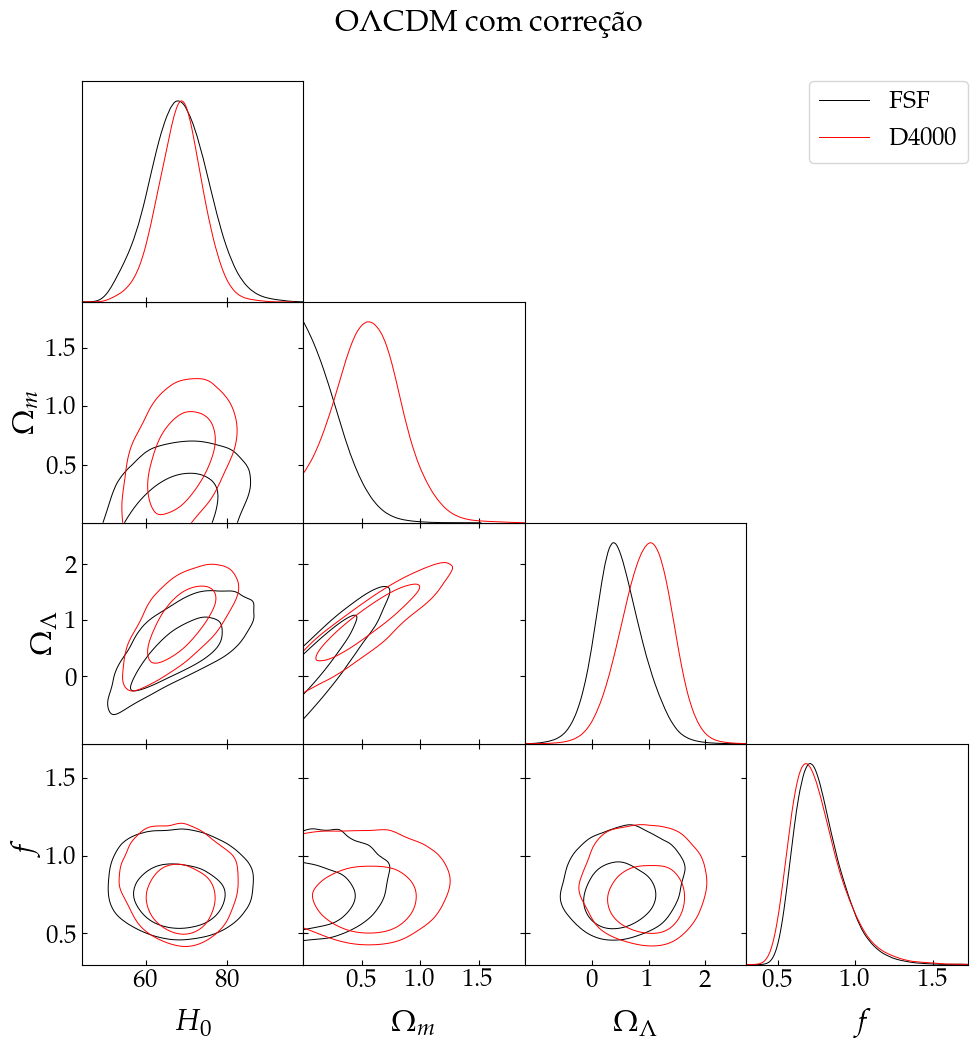

In [98]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzCF_FSF, gsamplesHzCF_D4000], ['H0', 'wm', 'wl', 'f'], filled=False, legend_labels=['FSF', 'D4000'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM com correção", fontsize=22, y=1.05)
g.export('fig/OLCDM-FSF-D4000-f.pdf')
plt.show()

In [102]:
print('FSF')
print('H0 = 68.22804 +7.27963 +15.09002 -7.28377 -14.58051 (median: 68.08603, ml: 66.96912)')
print('wm = 0.23216 +0.18003 +0.44969 -0.17583 -0.22426 (median: 0.19372, ml: 0.00000)')
print('wl = 0.48289 +0.42719 +0.92049 -0.40391 -0.81551 (median: 0.45097, ml: 0.09818)')
print('f = 0.77181 +0.15046 +0.38505 -0.15033 -0.24142 (median: 0.74667, ml: 0.64166)')
print('\nD4000')
print('H0 = 68.44455 +5.48757 +11.20031 -5.53226 -11.90934 (median: 68.56073, ml: 69.85074)')
print('wm = 0.56381 +0.26839 +0.58681 -0.28752 -0.50516 (median: 0.55345, ml: 0.56965)')
print('wl = 0.95743 +0.44469 +0.86617 -0.45464 -0.92827 (median: 0.97497, ml: 1.04315)')
print('f  = 0.75884 +0.16207 +0.42979 -0.16288 -0.25915 (median: 0.73097, ml: 0.61086)')

FSF
H0 = 68.22804 +7.27963 +15.09002 -7.28377 -14.58051 (median: 68.08603, ml: 66.96912)
wm = 0.23216 +0.18003 +0.44969 -0.17583 -0.22426 (median: 0.19372, ml: 0.00000)
wl = 0.48289 +0.42719 +0.92049 -0.40391 -0.81551 (median: 0.45097, ml: 0.09818)
f = 0.77181 +0.15046 +0.38505 -0.15033 -0.24142 (median: 0.74667, ml: 0.64166)

D4000
H0 = 68.44455 +5.48757 +11.20031 -5.53226 -11.90934 (median: 68.56073, ml: 69.85074)
wm = 0.56381 +0.26839 +0.58681 -0.28752 -0.50516 (median: 0.55345, ml: 0.56965)
wl = 0.95743 +0.44469 +0.86617 -0.45464 -0.92827 (median: 0.97497, ml: 1.04315)
f  = 0.75884 +0.16207 +0.42979 -0.16288 -0.25915 (median: 0.73097, ml: 0.61086)


## FLCDM
### Sem correção

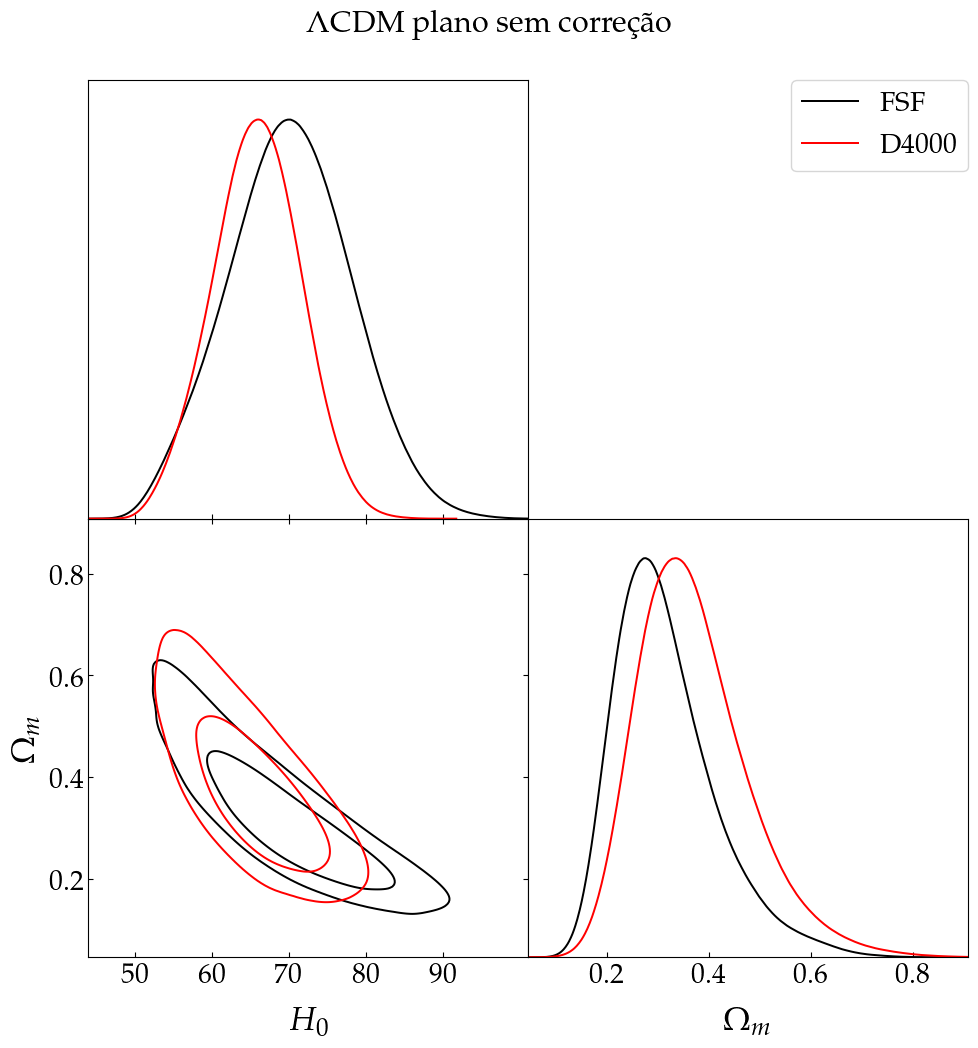

In [99]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF_FSF, gsamplesHzF_D4000], ['H0', 'wm'], filled=False, legend_labels=['FSF', 'D4000'], legend_loc='upper right')
g.fig.suptitle(r"$\Lambda$CDM plano sem correção", fontsize=22, y=1.05)
g.export('fig/FLCDM-FSF-D4000-no_f.pdf')
plt.show()

In [103]:
print('FSF')
print('H0 = 70.10869 +8.04326 +16.07986 -8.20055 -15.81833 (median: 70.07208, ml: 69.19300)')
print('wm = 0.31590 +0.09453 +0.25166 -0.09447 -0.15274 (median: 0.30002, ml: 0.24809)')
print('\nD4000')
print('H0 = 65.83189 +5.72259 +11.26889 -5.80527 -11.39527 (median: 65.88905, ml: 69.19300)')
print('wm = 0.37071 +0.10513 +0.26173 -0.10460 -0.17793 (median: 0.35723, ml: 0.24809)')

FSF
H0 = 70.10869 +8.04326 +16.07986 -8.20055 -15.81833 (median: 70.07208, ml: 69.19300)
wm = 0.31590 +0.09453 +0.25166 -0.09447 -0.15274 (median: 0.30002, ml: 0.24809)

D4000
H0 = 65.83189 +5.72259 +11.26889 -5.80527 -11.39527 (median: 65.88905, ml: 69.19300)
wm = 0.37071 +0.10513 +0.26173 -0.10460 -0.17793 (median: 0.35723, ml: 0.24809)


### Com correção

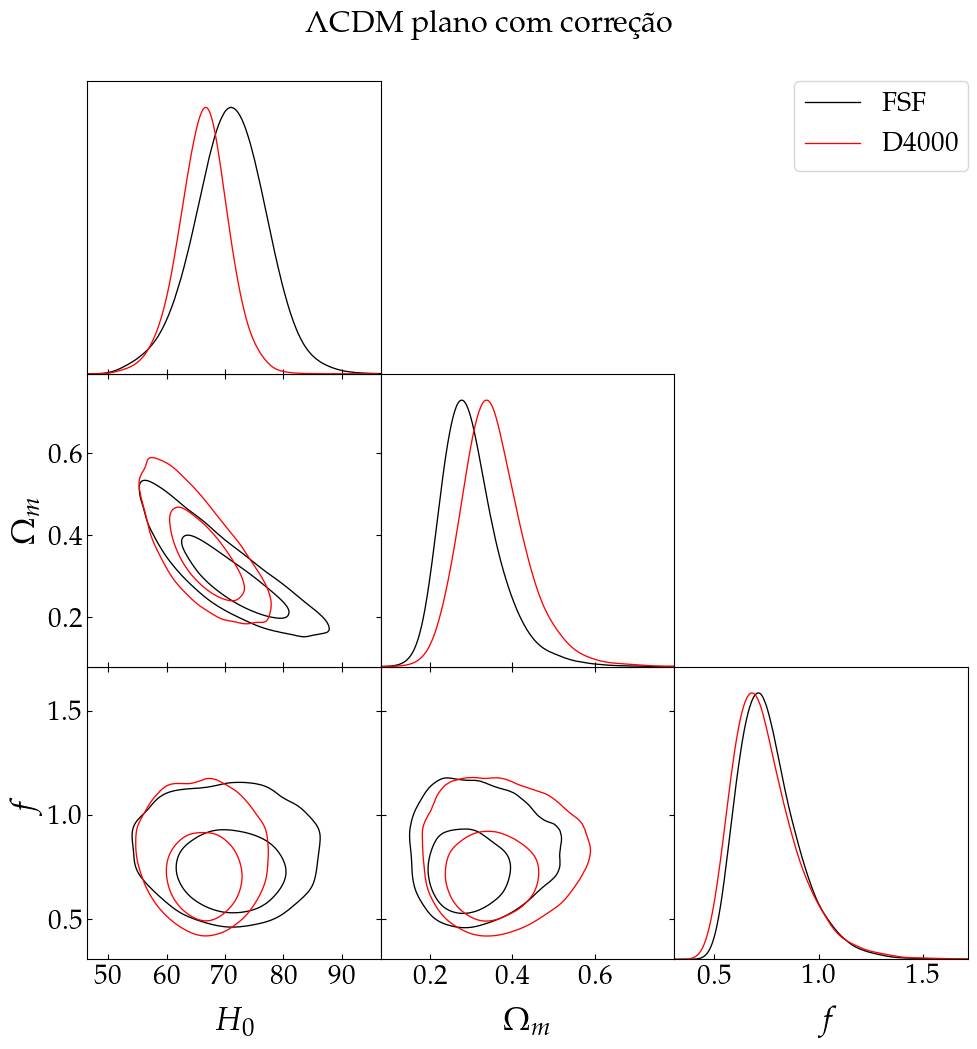

In [100]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzFf_FSF, gsamplesHzFf_D4000], ['H0', 'wm', 'f'], filled=False, legend_labels=['FSF', 'D4000'], legend_loc='upper right')
g.fig.suptitle(r"$\Lambda$CDM plano com correção", fontsize=22, y=1.05)
g.export('fig/FLCDM-FSF-D4000-f.pdf')
plt.show()

In [104]:
print('FSF')
print('H0 = 70.85518 +6.12929 +12.35600 -6.09713 -13.35139 (median: 70.94044, ml: 71.99081)')
print('wm = 0.30113 +0.06734 +0.18738 -0.06866 -0.11683 (median: 0.29068, ml: 0.27938)')
print('f = 0.76584 +0.14184 +0.37045 -0.14318 -0.23083 (median: 0.74246, ml: 0.66341)')
print('\nD4000')
print('H0 = 66.35168 +4.17342 +8.84663 -4.20142 -9.21634 (median: 66.44961, ml: 66.97014)')
print('wm = 0.35684 +0.07450 +0.19094 -0.07561 -0.13700 (median: 0.34831, ml: 0.33835)')
print('f = 0.74731 +0.15130 +0.41574 -0.15281 -0.24777 (median: 0.72008, ml: 0.62897)')

FSF
H0 = 70.85518 +6.12929 +12.35600 -6.09713 -13.35139 (median: 70.94044, ml: 71.99081)
wm = 0.30113 +0.06734 +0.18738 -0.06866 -0.11683 (median: 0.29068, ml: 0.27938)
f = 0.76584 +0.14184 +0.37045 -0.14318 -0.23083 (median: 0.74246, ml: 0.66341)

D4000
H0 = 66.35168 +4.17342 +8.84663 -4.20142 -9.21634 (median: 66.44961, ml: 66.97014)
wm = 0.35684 +0.07450 +0.19094 -0.07561 -0.13700 (median: 0.34831, ml: 0.33835)
f = 0.74731 +0.15130 +0.41574 -0.15281 -0.24777 (median: 0.72008, ml: 0.62897)
